# 🏦 BFSI Financial Fraud & Transaction Risk Analytics
---
**Problem:** A digital financial services organization is experiencing a surge in fraudulent transactions across UPI, wallets, card payments, and NEFT/RTGS channels. The current rule-based system is insufficient. We build an intelligent, data-driven fraud detection system.

**Dataset:** 40,250 transaction records with 22 features covering customer profile, transaction details, device behavior, and security signals.

---

## Step 1 — Understand the Problem Statement

### Business Context

| Dimension | Detail |
|-----------|--------|
| **Domain** | Banking, Financial Services & Insurance (BFSI) |
| **Problem Type** | Binary Classification (Fraud = Yes / No) |
| **Primary Challenge** | Class imbalance — fraudulent transactions are a minority |
| **Business Risk** | False Negatives (missed frauds) → financial loss, chargebacks, regulatory action |
| **Key Metric Priority** | Recall (catch as many frauds as possible) > Precision |

### Input Features Available
- **Customer Profile:** Age, Gender, Occupation, City Tier, Credit Score, Account Balance  
- **Transaction Details:** Amount, Type (UPI/Card/NEFT/RTGS/Wallet), Merchant Category, Hour  
- **Behavioral Signals:** Login Attempts, Failed Transactions, Days Since Last Transaction, Avg Monthly Transactions  
- **Security Signals:** Device Type, Transaction Location, IP Risk Score, VPN Used, Multiple Devices  

### Target Variable
- `IsFraud` → **Yes** (Fraudulent) / **No** (Legitimate)

---
## Step 2 — Load the Dataset

In [1]:
# Import all required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn — Preprocessing & Utilities
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif, RFE

# Sklearn — Models
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    VotingClassifier,
    StackingClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Sklearn — Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    confusion_matrix, classification_report,
    ConfusionMatrixDisplay
)

# Plot settings
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.facecolor'] = 'white'
sns.set_style('whitegrid')
SEED = 42
np.random.seed(SEED)

print("✅ Libraries loaded successfully.")

✅ Libraries loaded successfully.


In [2]:
# Load dataset
df = pd.read_csv('bfsi_fraud_risk_dataset.csv')

print(f"Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")

Dataset loaded: 40,250 rows × 22 columns


### 2.1 — Inspect the Dataset

In [3]:
# First look at the data
df.head()

,TransactionID,CustomerID,CustomerAge,CustomerGender,Occupation,CityTier,AccountBalance,TransactionAmount,TransactionType,MerchantCategory,...,LoginAttempts,FailedTransactions,DaysSinceLastTransaction,AvgMonthlyTransactions,CreditScore,TransactionLocation,IPRiskScore,VPNUsed,MultipleDevicesUsed,IsFraud
0,TXN_131493,CUST_98829,67,Male,Salaried,Tier-2,238725.62,972.78,UPI,Travel,...,1,1,4,43.13,719.0,Home City,1.00,No,No,No
1,TXN_126518,CUST_54311,72,Female,Self-Employed,Tier-3,327947.40,14730.80,Debit Card,Luxury,...,1,1,48,40.03,655.0,Home City,61.24,No,Yes,No
2,TXN_121417,CUST_22483,19,Female,Business,Tier-1,217429.36,27856.07,RTGS,Travel,...,1,1,37,46.92,630.0,Home City,37.70,No,No,Yes
3,TXN_127911,CUST_3593,34,Female,Government,Tier-3,178111.94,4440.02,Credit Card,Travel,...,1,0,19,25.90,775.0,Different City,40.96,No,No,No
4,TXN_112516,CUST_24544,69,Male,Retired,Tier-1,170786.19,8481.16,Wallet,Food,...,1,1,56,69.87,657.0,Different City,1.00,No,No,No


In [4]:
# Last few rows
df.tail()

,TransactionID,CustomerID,CustomerAge,CustomerGender,Occupation,CityTier,AccountBalance,TransactionAmount,TransactionType,MerchantCategory,...,LoginAttempts,FailedTransactions,DaysSinceLastTransaction,AvgMonthlyTransactions,CreditScore,TransactionLocation,IPRiskScore,VPNUsed,MultipleDevicesUsed,IsFraud
40245,TXN_107127,CUST_89047,59,Male,Self-Employed,Tier-1,109613.78,1123.20,NEFT,NaN,...,1,0,5,30.79,797.0,Different City,25.41,Yes,No,No
40246,TXN_139559,CUST_60966,30,Female,Retired,Tier-2,215786.85,906.51,NEFT,Healthcare,...,0,1,36,39.27,679.0,Different City,28.86,No,No,No
40247,TXN_120587,CUST_75873,20,Male,Student,Tier-1,5000.00,54220.37,Credit Card,Luxury,...,3,1,34,41.15,899.0,Different City,56.01,Yes,No,No
40248,TXN_124818,CUST_31002,24,Male,Salaried,Tier-3,238182.20,39138.48,UPI,Luxury,...,4,1,54,16.85,788.0,Home City,37.27,No,No,Yes
40249,TXN_108992,CUST_8213,41,Female,Business,Tier-1,308457.88,6263.63,Credit Card,NaN,...,1,0,6,13.86,697.0,Home City,66.14,No,No,No


In [5]:
# Shape of the dataset
print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")

Rows    : 40,250
Columns : 22


In [6]:
# Column names and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40250 entries, 0 to 40249
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   TransactionID             40250 non-null  object 
 1   CustomerID                40250 non-null  object 
 2   CustomerAge               40250 non-null  int64  
 3   CustomerGender            40250 non-null  object 
 4   Occupation                40250 non-null  object 
 5   CityTier                  40250 non-null  object 
 6   AccountBalance            40250 non-null  float64
 7   TransactionAmount         39041 non-null  float64
 8   TransactionType           40250 non-null  object 
 9   MerchantCategory          39046 non-null  object 
 10  TransactionHour           40250 non-null  int64  
 11  DeviceType                40250 non-null  object 
 12  LoginAttempts             40250 non-null  int64  
 13  FailedTransactions        40250 non-null  int64  
 14  DaysSi

In [7]:
# Statistical summary of numeric columns
df.describe()

,CustomerAge,AccountBalance,TransactionAmount,TransactionHour,LoginAttempts,FailedTransactions,DaysSinceLastTransaction,AvgMonthlyTransactions,CreditScore,IPRiskScore
count,40250.000000,40250.000000,39041.000000,40250.000000,40250.000000,40250.000000,40250.000000,40250.000000,39037.000000,39042.000000
mean,45.958137,152040.422016,12935.850717,11.431652,1.494733,0.802882,29.503702,35.168671,719.340523,35.418021
std,16.423498,85417.063527,17743.360126,6.915031,1.221311,0.896243,17.290152,14.897340,79.205460,19.241393
min,18.000000,5000.000000,100.000000,0.000000,0.000000,0.000000,0.000000,1.000000,408.000000,1.000000
25%,32.000000,89983.482500,3513.980000,5.000000,1.000000,0.000000,14.000000,25.000000,665.000000,21.580000
50%,46.000000,149981.610000,8459.100000,11.000000,1.000000,1.000000,30.000000,35.040000,720.000000,35.110000
75%,60.000000,209941.577500,16835.720000,17.000000,2.000000,1.000000,44.000000,45.270000,773.000000,48.480000
max,74.000000,572502.540000,472900.640000,23.000000,9.000000,6.000000,59.000000,90.470000,900.000000,100.000000


In [8]:
# Statistical summary of categorical columns
df.describe(include='object')

,TransactionID,CustomerID,CustomerGender,Occupation,CityTier,TransactionType,MerchantCategory,DeviceType,TransactionLocation,VPNUsed,MultipleDevicesUsed,IsFraud
count,40250,40250,40250,40250,40250,40250,39046,40250,40250,40250,40250,40250
unique,40000,32870,2,6,4,7,8,4,3,2,2,2
top,TXN_105462,CUST_16765,Female,Salaried,Tier-1,UPI,Healthcare,Android,Home City,No,No,No
freq,2,6,20165,6753,17619,6670,4939,10128,28961,35361,33072,29970


In [9]:
# Target variable distribution
print("Target Variable — IsFraud:")
print(df['IsFraud'].value_counts())
print()
print(df['IsFraud'].value_counts(normalize=True).mul(100).round(2).astype(str) + ' %')

Target Variable — IsFraud:
IsFraud
No     29970
Yes    10280
Name: count, dtype: int64

IsFraud
No     74.46 %
Yes    25.54 %
Name: proportion, dtype: object


---
## Step 3 — Exploratory Data Analysis (EDA)

### 3.1 — Identify Missing Values

In [10]:
# Count and percentage of missing values per column
missing_count = df.isnull().sum()
missing_pct   = (df.isnull().sum() / len(df) * 100).round(2)

missing_df = pd.DataFrame({'Missing Count': missing_count,
                            'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print("Columns with missing values:")
print(missing_df)

Columns with missing values:
                   Missing Count  Missing %
CreditScore                 1213       3.01
TransactionAmount           1209       3.00
IPRiskScore                 1208       3.00
MerchantCategory            1204       2.99


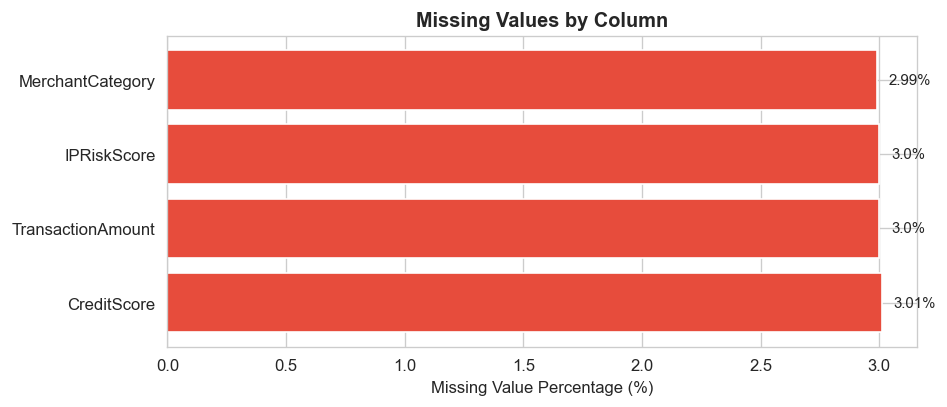

In [11]:
# Visualise missing values
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.barh(missing_df.index, missing_df['Missing %'], color='#e74c3c', edgecolor='white')
ax.set_xlabel('Missing Value Percentage (%)')
ax.set_title('Missing Values by Column', fontweight='bold')
for i, v in enumerate(missing_df['Missing %']):
    ax.text(v + 0.05, i, f'{v}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

In [12]:
# Fill missing numeric columns with MEDIAN (robust to outliers)
for col in ['TransactionAmount', 'CreditScore', 'IPRiskScore']:
    median_val = df[col].median()
    df[col].fillna(median_val, inplace=True)
    print(f"  {col}: filled with median = {median_val:.2f}")

# Fill missing categorical column with MODE
mode_val = df['MerchantCategory'].mode()[0]
df['MerchantCategory'].fillna(mode_val, inplace=True)
print(f"  MerchantCategory: filled with mode = '{mode_val}'")

print(f"\nTotal missing values remaining: {df.isnull().sum().sum()}")

  TransactionAmount: filled with median = 8459.10
  CreditScore: filled with median = 720.00
  IPRiskScore: filled with median = 35.11
  MerchantCategory: filled with mode = 'Healthcare'

Total missing values remaining: 0


### 3.2 — Remove Duplicate Records

In [13]:
# Check for duplicate rows
print(f"Duplicate rows found: {df.duplicated().sum()}")

Duplicate rows found: 231


In [14]:
# Remove duplicates
before = len(df)
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
print(f"Rows before : {before:,}")
print(f"Rows after  : {len(df):,}")
print(f"Removed     : {before - len(df)} duplicate rows")

Rows before : 40,250
Rows after  : 40,019
Removed     : 231 duplicate rows


### 3.3 — Handle Inconsistent Data

In [15]:
# Check unique values in categorical columns for inconsistencies
cat_cols = ['TransactionType', 'CityTier', 'CustomerGender', 'VPNUsed',
            'MultipleDevicesUsed', 'Occupation', 'DeviceType',
            'MerchantCategory', 'TransactionLocation']

for col in cat_cols:
    print(f"{col}: {sorted(df[col].dropna().unique())}")

TransactionType: ['Credit Card', 'Debit Card', 'NEFT', 'RTGS', 'UPI', 'Wallet', 'credit card']
CityTier: ['Tier-1', 'Tier-2', 'Tier-3', 'tier-1']
CustomerGender: ['Female', 'Male']
VPNUsed: ['No', 'Yes']
MultipleDevicesUsed: ['No', 'Yes']
Occupation: ['Business', 'Government', 'Retired', 'Salaried', 'Self-Employed', 'Student']
DeviceType: ['Android', 'Desktop', 'Tablet', 'iPhone']
MerchantCategory: ['Electronics', 'Food', 'Gaming', 'Healthcare', 'Luxury', 'Retail', 'Travel', 'Utilities']
TransactionLocation: ['Different City', 'Home City', 'International']


In [16]:
# Fix: standardise case inconsistencies
df['TransactionType'] = df['TransactionType'].str.strip().str.title()
df['CityTier']        = df['CityTier'].str.strip().str.title()

print("After cleaning:")
print("TransactionType:", sorted(df['TransactionType'].unique()))
print("CityTier       :", sorted(df['CityTier'].unique()))

After cleaning:
TransactionType: ['Credit Card', 'Debit Card', 'Neft', 'Rtgs', 'Upi', 'Wallet']
CityTier       : ['Tier-1', 'Tier-2', 'Tier-3']


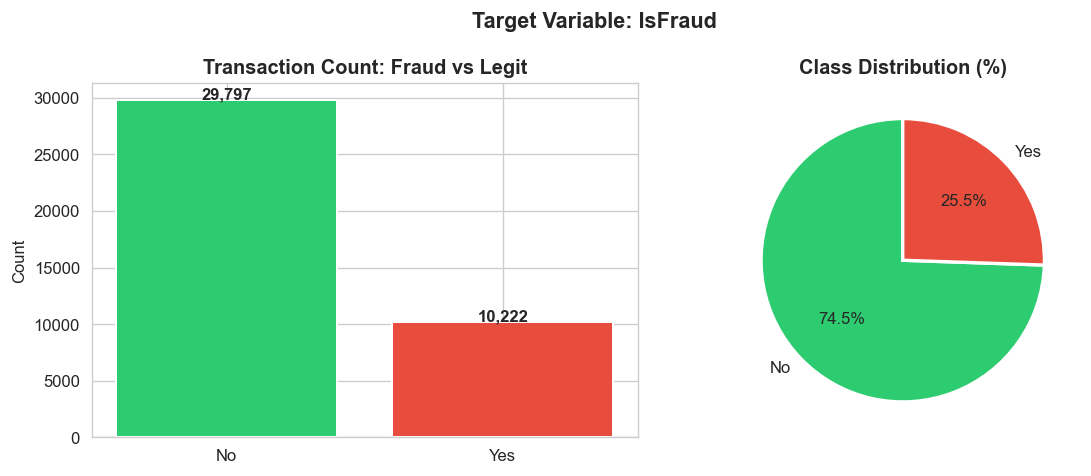

In [17]:
# Visualise target variable class balance
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

counts = df['IsFraud'].value_counts()
axes[0].bar(counts.index, counts.values,
            color=['#2ecc71', '#e74c3c'], edgecolor='white', linewidth=1.2)
axes[0].set_title('Transaction Count: Fraud vs Legit', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c'],
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class Distribution (%)', fontweight='bold')

plt.suptitle('Target Variable: IsFraud', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

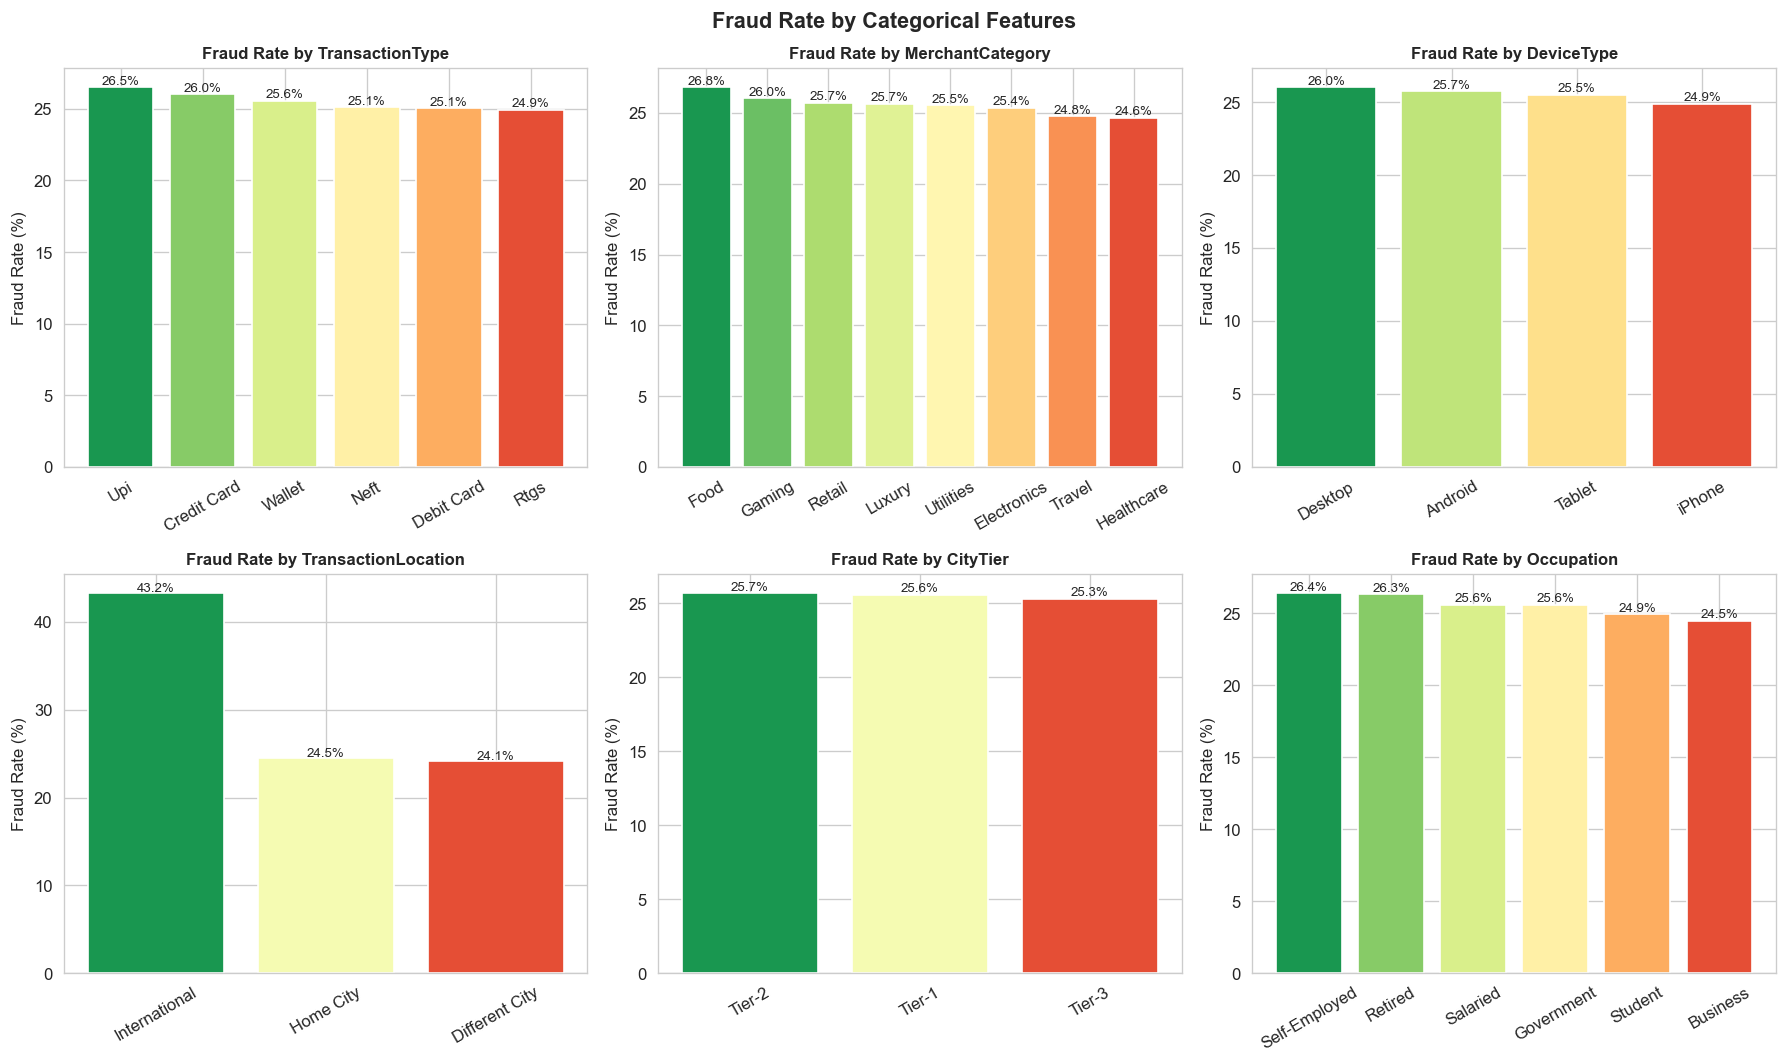

In [18]:
# Distribution of key categorical features vs Fraud
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

cat_plot_cols = ['TransactionType', 'MerchantCategory', 'DeviceType',
                 'TransactionLocation', 'CityTier', 'Occupation']

for ax, col in zip(axes, cat_plot_cols):
    fraud_rate = df.groupby(col)['IsFraud'].apply(
        lambda x: (x == 'Yes').mean() * 100
    ).sort_values(ascending=False)
    colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.85, len(fraud_rate)))
    ax.bar(fraud_rate.index, fraud_rate.values, color=colors, edgecolor='white')
    ax.set_title(f'Fraud Rate by {col}', fontweight='bold', fontsize=10)
    ax.set_ylabel('Fraud Rate (%)')
    ax.tick_params(axis='x', rotation=30)
    for i, v in enumerate(fraud_rate.values):
        ax.text(i, v + 0.2, f'{v:.1f}%', ha='center', fontsize=8)

plt.suptitle('Fraud Rate by Categorical Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

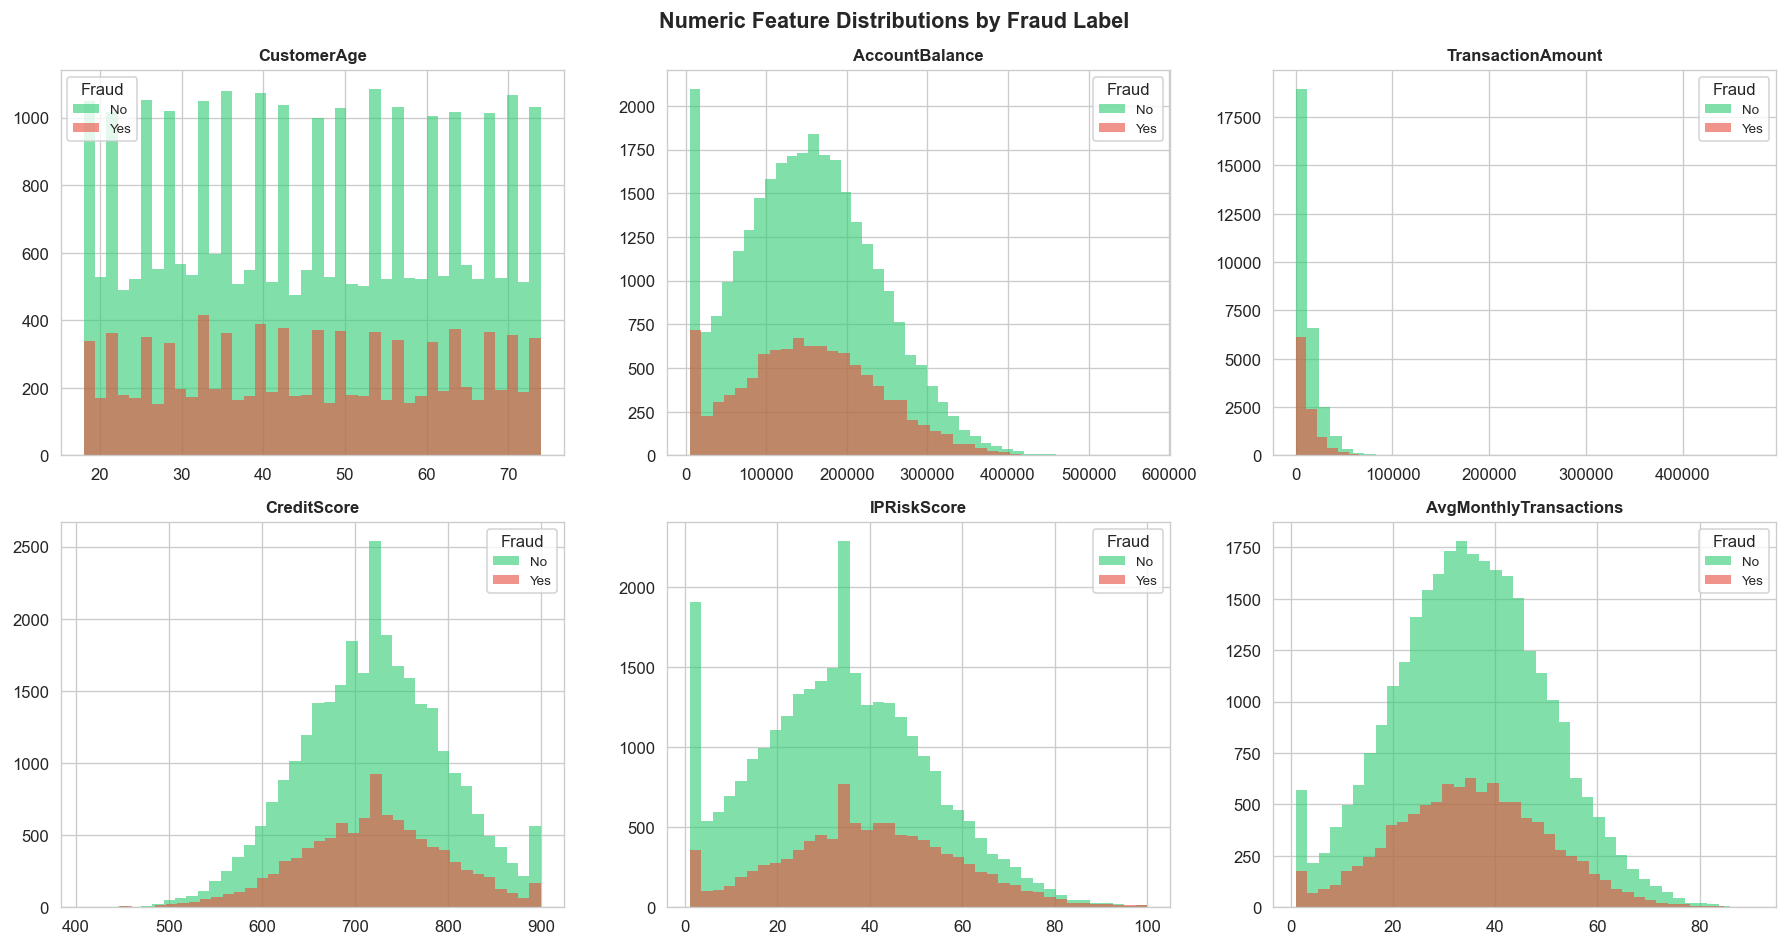

In [19]:
# Distribution of numeric features
num_cols = ['CustomerAge', 'AccountBalance', 'TransactionAmount',
            'CreditScore', 'IPRiskScore', 'AvgMonthlyTransactions']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    for label, color in [('No', '#2ecc71'), ('Yes', '#e74c3c')]:
        ax.hist(df[df['IsFraud'] == label][col], bins=40,
                alpha=0.6, color=color, label=label, edgecolor='none')
    ax.set_title(col, fontweight='bold', fontsize=10)
    ax.set_xlabel('')
    ax.legend(title='Fraud', fontsize=8)

plt.suptitle('Numeric Feature Distributions by Fraud Label', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

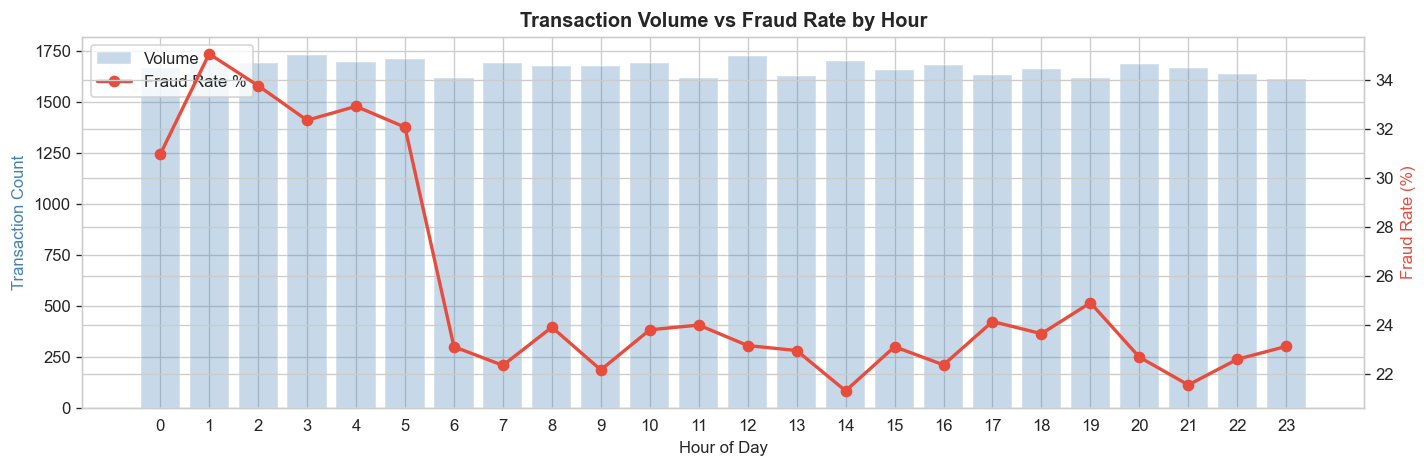

In [20]:
# Hourly fraud pattern
hourly = df.groupby('TransactionHour').apply(
    lambda x: pd.Series({
        'FraudRate': (x['IsFraud'] == 'Yes').mean() * 100,
        'TxnCount' : len(x)
    })
).reset_index()

fig, ax1 = plt.subplots(figsize=(12, 4))
ax2 = ax1.twinx()
ax1.bar(hourly['TransactionHour'], hourly['TxnCount'], alpha=0.3, color='steelblue', label='Volume')
ax2.plot(hourly['TransactionHour'], hourly['FraudRate'], color='#e74c3c',
         marker='o', linewidth=2, label='Fraud Rate %')
ax1.set_xlabel('Hour of Day')
ax1.set_ylabel('Transaction Count', color='steelblue')
ax2.set_ylabel('Fraud Rate (%)', color='#e74c3c')
ax1.set_title('Transaction Volume vs Fraud Rate by Hour', fontweight='bold')
ax1.set_xticks(range(24))
lines1, lab1 = ax1.get_legend_handles_labels()
lines2, lab2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, lab1 + lab2, loc='upper left')
plt.tight_layout()
plt.show()

### 3.4 — Detect and Treat Outliers

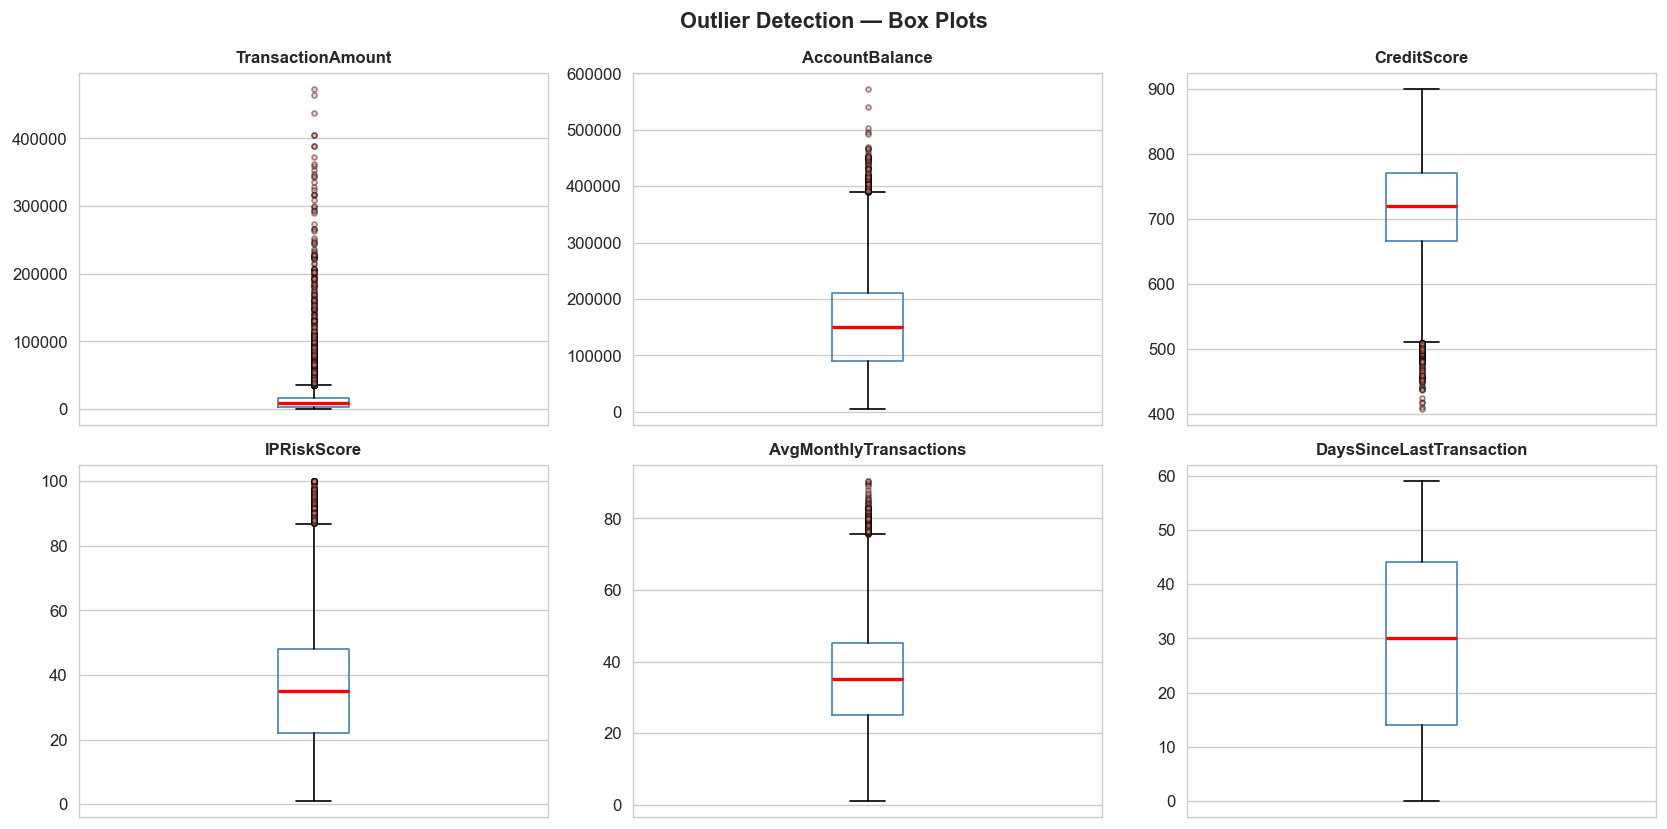

In [21]:
# Box plots to detect outliers in numeric features
outlier_cols = ['TransactionAmount', 'AccountBalance', 'CreditScore',
                'IPRiskScore', 'AvgMonthlyTransactions', 'DaysSinceLastTransaction']

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()

for ax, col in zip(axes, outlier_cols):
    ax.boxplot(df[col].dropna(),
               boxprops=dict(color='steelblue'),
               medianprops=dict(color='red', linewidth=2),
               flierprops=dict(marker='o', markerfacecolor='salmon',
                               markersize=3, alpha=0.4))
    ax.set_title(col, fontweight='bold', fontsize=10)
    ax.set_xticks([])

plt.suptitle('Outlier Detection — Box Plots', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [22]:
# Treat outliers using IQR-based capping (Winsorisation)
# We cap rather than remove — preserving record count for fraud detection

def cap_outliers_iqr(df, col, factor=1.5):
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - factor * IQR
    upper = Q3 + factor * IQR
    before_count = ((df[col] < lower) | (df[col] > upper)).sum()
    df[col] = df[col].clip(lower=lower, upper=upper)
    print(f"  {col:35s}: {before_count:4d} outliers capped  [Lower={lower:.1f}, Upper={upper:.1f}]")
    return df

treat_cols = ['TransactionAmount', 'AccountBalance', 'IPRiskScore', 'AvgMonthlyTransactions']

print("Outlier Treatment (IQR Capping):")
for col in treat_cols:
    df = cap_outliers_iqr(df, col)

print("\nDone.")

Outlier Treatment (IQR Capping):
  TransactionAmount                  : 2261 outliers capped  [Lower=-15622.5, Upper=35751.8]
  AccountBalance                     :  144 outliers capped  [Lower=-89783.1, Upper=389700.1]
  IPRiskScore                        :  197 outliers capped  [Lower=-16.7, Upper=86.9]
  AvgMonthlyTransactions             :  133 outliers capped  [Lower=-5.4, Upper=75.6]

Done.


### 3.5 — Encode Categorical Features

In [23]:
# Encode target variable
df['IsFraud'] = df['IsFraud'].map({'No': 0, 'Yes': 1})
print("IsFraud encoded:")
print(df['IsFraud'].value_counts())

IsFraud encoded:
IsFraud
0    29797
1    10222
Name: count, dtype: int64


In [24]:
# Encode binary Yes/No columns directly
df['VPNUsed']             = df['VPNUsed'].map({'No': 0, 'Yes': 1})
df['MultipleDevicesUsed'] = df['MultipleDevicesUsed'].map({'No': 0, 'Yes': 1})
df['CustomerGender']      = df['CustomerGender'].map({'Male': 0, 'Female': 1})

print("Binary columns encoded.")

# Label encode remaining nominal categorical columns
label_encode_cols = ['Occupation', 'CityTier', 'TransactionType',
                     'MerchantCategory', 'DeviceType', 'TransactionLocation']

le = LabelEncoder()
for col in label_encode_cols:
    df[col] = le.fit_transform(df[col].astype(str))
    print(f"  {col} encoded.")

print("\nAll categorical features encoded.")

Binary columns encoded.
  Occupation encoded.
  CityTier encoded.
  TransactionType encoded.
  MerchantCategory encoded.
  DeviceType encoded.
  TransactionLocation encoded.

All categorical features encoded.


In [25]:
# Drop ID columns — not useful for modelling
df.drop(columns=['TransactionID', 'CustomerID'], inplace=True)

print(f"Dataset shape after encoding: {df.shape}")
df.head()

Dataset shape after encoding: (40019, 20)


,CustomerAge,CustomerGender,Occupation,CityTier,AccountBalance,TransactionAmount,TransactionType,MerchantCategory,TransactionHour,DeviceType,LoginAttempts,FailedTransactions,DaysSinceLastTransaction,AvgMonthlyTransactions,CreditScore,TransactionLocation,IPRiskScore,VPNUsed,MultipleDevicesUsed,IsFraud
0,67,0,3,1,238725.62,972.78,4,6,0,3,1,1,4,43.13,719.0,1,1.00,0,0,0
1,72,1,4,2,327947.40,14730.80,1,4,8,2,1,1,48,40.03,655.0,1,61.24,0,1,0
2,19,1,0,0,217429.36,27856.07,3,6,10,0,1,1,37,46.92,630.0,1,37.70,0,0,1
3,34,1,1,2,178111.94,4440.02,0,6,10,3,1,0,19,25.90,775.0,0,40.96,0,0,0
4,69,0,2,0,170786.19,8481.16,5,1,8,3,1,1,56,69.87,657.0,0,1.00,0,0,0


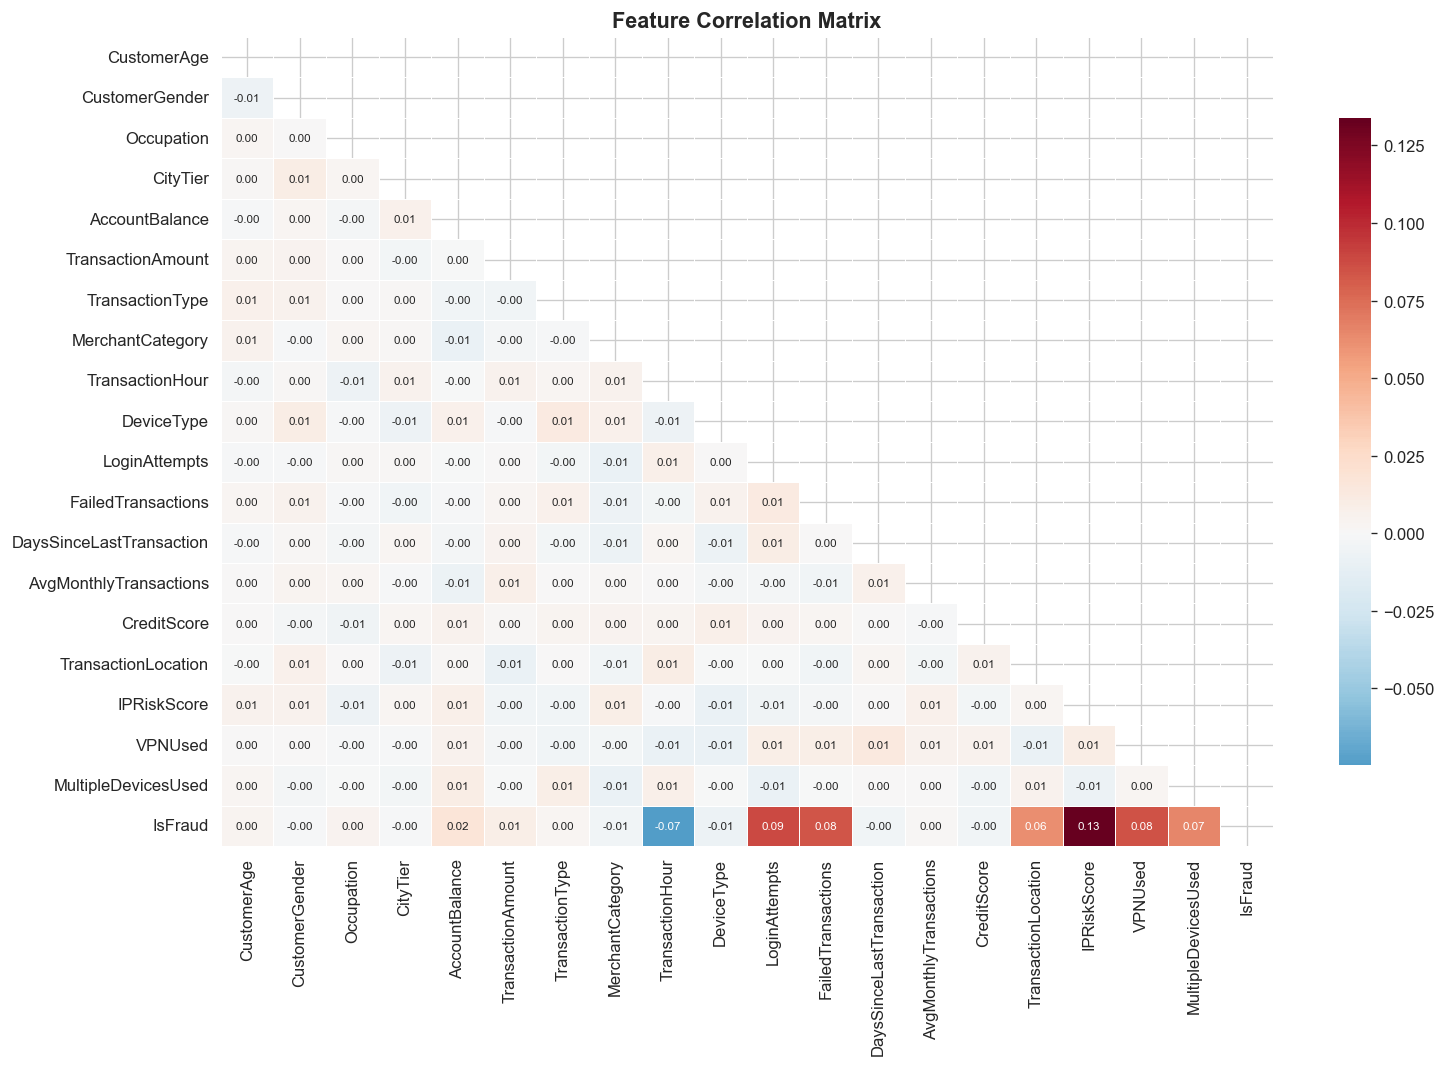

In [26]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(13, 9))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.4, ax=ax, cbar_kws={'shrink': 0.8},
            annot_kws={'size': 7})
ax.set_title('Feature Correlation Matrix', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

### 3.6 — Scale Numerical Features

In [27]:
# Separate features and target
TARGET   = 'IsFraud'
FEATURES = [c for c in df.columns if c != TARGET]

X = df[FEATURES].copy()
y = df[TARGET].copy()

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Features: {FEATURES}")

X shape: (40019, 19)
y shape: (40019,)
Features: ['CustomerAge', 'CustomerGender', 'Occupation', 'CityTier', 'AccountBalance', 'TransactionAmount', 'TransactionType', 'MerchantCategory', 'TransactionHour', 'DeviceType', 'LoginAttempts', 'FailedTransactions', 'DaysSinceLastTransaction', 'AvgMonthlyTransactions', 'CreditScore', 'TransactionLocation', 'IPRiskScore', 'VPNUsed', 'MultipleDevicesUsed']


In [28]:
# Apply StandardScaler to all numeric features
# Note: We scale AFTER splitting to prevent data leakage;
#       here we scale the full X to prepare for feature selection,
#       and will re-scale on the train set only after splitting.

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=FEATURES)

print("Features scaled with StandardScaler.")
X_scaled.describe().T[['mean', 'std', 'min', 'max']].round(3)

Features scaled with StandardScaler.


,mean,std,min,max
CustomerAge,0.0,1.0,-1.702,1.707
CustomerGender,0.0,1.0,-1.002,0.998
Occupation,-0.0,1.0,-1.462,1.469
CityTier,-0.0,1.0,-0.965,1.649
AccountBalance,0.0,1.0,-1.727,2.795
TransactionAmount,-0.0,1.0,-1.136,2.412
TransactionType,0.0,1.0,-1.427,1.481
MerchantCategory,-0.0,1.0,-1.544,1.558
TransactionHour,-0.0,1.0,-1.653,1.673
DeviceType,0.0,1.0,-1.338,1.347


---
## Step 4 — Perform Feature Selection

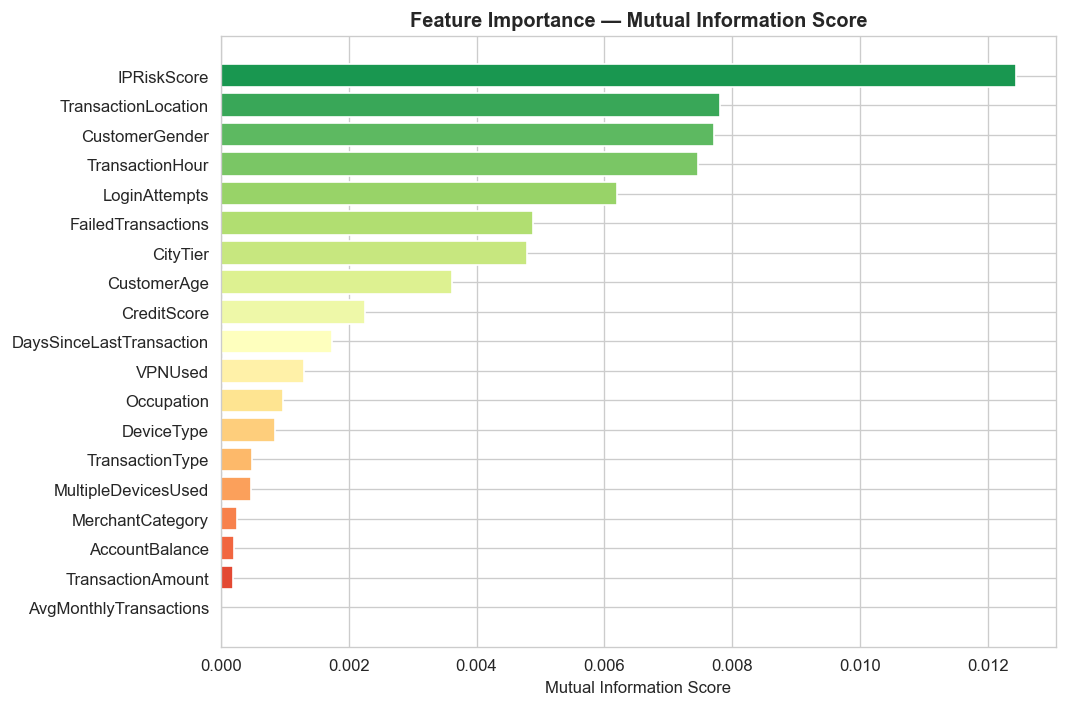

IPRiskScore                 0.012440
TransactionLocation         0.007811
CustomerGender              0.007710
TransactionHour             0.007469
LoginAttempts               0.006196
FailedTransactions          0.004887
CityTier                    0.004788
CustomerAge                 0.003622
CreditScore                 0.002250
DaysSinceLastTransaction    0.001737
VPNUsed                     0.001299
Occupation                  0.000967
DeviceType                  0.000853
TransactionType             0.000494
MultipleDevicesUsed         0.000479
MerchantCategory            0.000247
AccountBalance              0.000213
TransactionAmount           0.000189
AvgMonthlyTransactions      0.000000
dtype: float64


In [29]:
# Method 1: Mutual Information — measures dependency between each feature and target
mi_scores = mutual_info_classif(X, y, random_state=SEED)
mi_series = pd.Series(mi_scores, index=FEATURES).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
colors = plt.cm.RdYlGn(np.linspace(0.1, 0.9, len(mi_series)))
ax.barh(mi_series.index[::-1], mi_series.values[::-1], color=colors, edgecolor='white')
ax.set_title('Feature Importance — Mutual Information Score', fontweight='bold', fontsize=12)
ax.set_xlabel('Mutual Information Score')
plt.tight_layout()
plt.show()

print(mi_series)

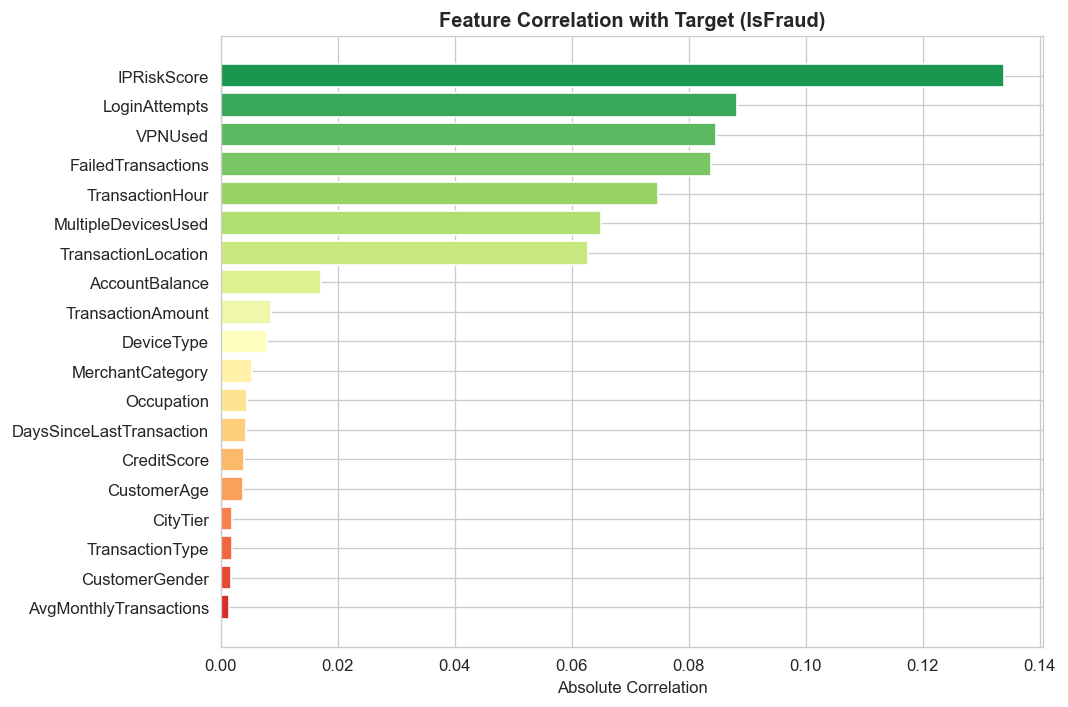

IPRiskScore                 0.133888
LoginAttempts               0.088287
VPNUsed                     0.084712
FailedTransactions          0.083778
TransactionHour             0.074774
MultipleDevicesUsed         0.065030
TransactionLocation         0.062788
AccountBalance              0.017155
TransactionAmount           0.008610
DeviceType                  0.007911
MerchantCategory            0.005288
Occupation                  0.004544
DaysSinceLastTransaction    0.004318
CreditScore                 0.004048
CustomerAge                 0.003718
CityTier                    0.001899
TransactionType             0.001865
CustomerGender              0.001754
AvgMonthlyTransactions      0.001438
Name: IsFraud, dtype: float64


In [30]:
# Method 2: Correlation with target
target_corr = df.corr()['IsFraud'].drop('IsFraud').abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
colors = plt.cm.RdYlGn(np.linspace(0.1, 0.9, len(target_corr)))
ax.barh(target_corr.index[::-1], target_corr.values[::-1], color=colors, edgecolor='white')
ax.set_title('Feature Correlation with Target (IsFraud)', fontweight='bold', fontsize=12)
ax.set_xlabel('Absolute Correlation')
plt.tight_layout()
plt.show()

print(target_corr)

In [31]:
# Select top features based on mutual information score
# Keep features with MI score > 0 (informative) and drop weakest
SELECTED_FEATURES = mi_series[mi_series > 0.001].index.tolist()
print(f"Selected {len(SELECTED_FEATURES)} features out of {len(FEATURES)}:")
print(SELECTED_FEATURES)

Selected 11 features out of 19:
['IPRiskScore', 'TransactionLocation', 'CustomerGender', 'TransactionHour', 'LoginAttempts', 'FailedTransactions', 'CityTier', 'CustomerAge', 'CreditScore', 'DaysSinceLastTransaction', 'VPNUsed']


In [32]:
# Final X with selected features
X_final = X[SELECTED_FEATURES]
print(f"Final feature matrix shape: {X_final.shape}")

Final feature matrix shape: (40019, 11)


---
## Step 5 — Split Train and Test Data

In [33]:
# 80% Train | 20% Test | Stratified to preserve class ratio
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

print(f"Training set   : {X_train.shape[0]:,} rows")
print(f"Test set       : {X_test.shape[0]:,} rows")
print()
print(f"Train fraud %  : {y_train.mean()*100:.2f}%")
print(f"Test  fraud %  : {y_test.mean()*100:.2f}%")

Training set   : 32,015 rows
Test set       : 8,004 rows

Train fraud %  : 25.54%
Test  fraud %  : 25.54%


In [34]:
# Scale features — fit on train only, transform both train and test (no leakage)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print("Scaling done. Train mean ≈ 0, std ≈ 1 (StandardScaler applied).")

Scaling done. Train mean ≈ 0, std ≈ 1 (StandardScaler applied).


---
## Step 6 — Build Baseline Models

In [35]:
# Helper function to evaluate any trained model
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    y_pred  = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]

    metrics = {
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_te, y_pred), 4),
        'Precision': round(precision_score(y_te, y_pred), 4),
        'Recall'   : round(recall_score(y_te, y_pred), 4),
        'F1-Score' : round(f1_score(y_te, y_pred), 4),
        'ROC-AUC'  : round(roc_auc_score(y_te, y_proba), 4),
    }
    return metrics, model, y_pred, y_proba

# Store all results
all_results  = []
trained_models = {}
all_preds    = {}
all_probas   = {}

print("Evaluation helper ready.")

Evaluation helper ready.


### 6.1 — Implement KNN

In [36]:
# K-Nearest Neighbors
# Rule of thumb: k = sqrt(n_samples)
import math
k_val = int(math.sqrt(len(X_train)))
if k_val % 2 == 0:
    k_val += 1   # keep odd to avoid ties
print(f"Chosen k = {k_val}")

knn = KNeighborsClassifier(n_neighbors=k_val, metric='euclidean', n_jobs=-1)
metrics_knn, trained_knn, pred_knn, proba_knn = evaluate_model(
    'KNN', knn, X_train_sc, y_train, X_test_sc, y_test)

all_results.append(metrics_knn)
trained_models['KNN'] = trained_knn
all_preds['KNN']   = pred_knn
all_probas['KNN']  = proba_knn

print(f"\nKNN Results:")
for k, v in metrics_knn.items():
    print(f"  {k:12s}: {v}")

Chosen k = 179

KNN Results:
  Model       : KNN
  Accuracy    : 0.7449
  Precision   : 1.0
  Recall      : 0.001
  F1-Score    : 0.002
  ROC-AUC     : 0.6401


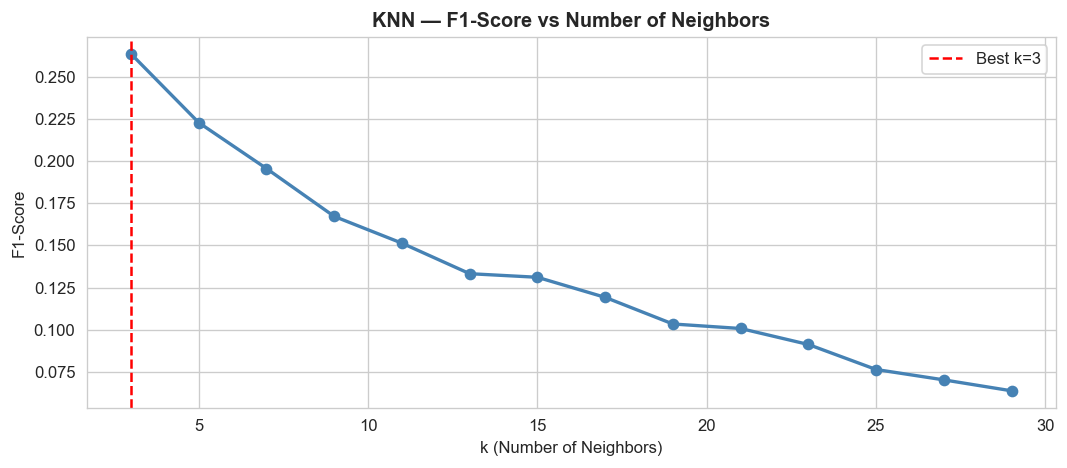

Optimal k = 3  |  Best F1 = 0.2639


In [37]:
# KNN: Try different k values to find optimal
k_range   = range(3, 30, 2)
k_scores  = []

for k in k_range:
    knn_k = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
    knn_k.fit(X_train_sc, y_train)
    score = f1_score(y_test, knn_k.predict(X_test_sc))
    k_scores.append(score)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(list(k_range), k_scores, marker='o', color='steelblue', linewidth=2)
ax.axvline(list(k_range)[np.argmax(k_scores)], color='red', linestyle='--',
           label=f'Best k={list(k_range)[np.argmax(k_scores)]}')
ax.set_xlabel('k (Number of Neighbors)')
ax.set_ylabel('F1-Score')
ax.set_title('KNN — F1-Score vs Number of Neighbors', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

best_k = list(k_range)[np.argmax(k_scores)]
print(f"Optimal k = {best_k}  |  Best F1 = {max(k_scores):.4f}")

### 6.2 — Implement Ensemble Models

> **What are Ensemble Models?**  
> Ensemble methods combine multiple individual learners to produce a stronger, more generalizable model.  
> - **Bagging** (Random Forest) — reduces variance by averaging many trees trained on bootstrap samples  
> - **Boosting** (AdaBoost, GBM) — reduces bias by sequentially correcting errors of previous learners  

### 6.3 — Train Random Forest

In [38]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    class_weight='balanced',   # handles class imbalance
    random_state=SEED,
    n_jobs=-1
)

metrics_rf, trained_rf, pred_rf, proba_rf = evaluate_model(
    'Random Forest', rf, X_train_sc, y_train, X_test_sc, y_test)

all_results.append(metrics_rf)
trained_models['Random Forest'] = trained_rf
all_preds['Random Forest']  = pred_rf
all_probas['Random Forest'] = proba_rf

print("Random Forest Results:")
for k, v in metrics_rf.items():
    print(f"  {k:12s}: {v}")

Random Forest Results:
  Model       : Random Forest
  Accuracy    : 0.6414
  Precision   : 0.3626
  Recall      : 0.5333
  F1-Score    : 0.4317
  ROC-AUC     : 0.6469


### 6.4 — Train AdaBoost

In [39]:
ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=2),
    n_estimators=100,
    learning_rate=0.5,
    random_state=SEED
)

metrics_ada, trained_ada, pred_ada, proba_ada = evaluate_model(
    'AdaBoost', ada, X_train_sc, y_train, X_test_sc, y_test)

all_results.append(metrics_ada)
trained_models['AdaBoost'] = trained_ada
all_preds['AdaBoost']  = pred_ada
all_probas['AdaBoost'] = proba_ada

print("AdaBoost Results:")
for k, v in metrics_ada.items():
    print(f"  {k:12s}: {v}")

AdaBoost Results:
  Model       : AdaBoost
  Accuracy    : 0.7445
  Precision   : 0.4975
  Recall      : 0.0494
  F1-Score    : 0.0899
  ROC-AUC     : 0.6538


### 6.5 — Train Gradient Boosting

In [40]:
gbm = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    random_state=SEED
)

metrics_gbm, trained_gbm, pred_gbm, proba_gbm = evaluate_model(
    'Gradient Boosting', gbm, X_train_sc, y_train, X_test_sc, y_test)

all_results.append(metrics_gbm)
trained_models['Gradient Boosting'] = trained_gbm
all_preds['Gradient Boosting']  = pred_gbm
all_probas['Gradient Boosting'] = proba_gbm

print("Gradient Boosting Results:")
for k, v in metrics_gbm.items():
    print(f"  {k:12s}: {v}")

Gradient Boosting Results:
  Model       : Gradient Boosting
  Accuracy    : 0.7429
  Precision   : 0.4754
  Recall      : 0.066
  F1-Score    : 0.116
  ROC-AUC     : 0.6463


---
## Step 7 — Build Voting Ensemble & Stacking Ensemble

### 7.1 — Voting Ensemble (Soft Voting)

In [41]:
# Soft Voting — averages predicted probabilities of each model
voting_clf = VotingClassifier(
    estimators=[
        ('knn', KNeighborsClassifier(n_neighbors=best_k, n_jobs=-1)),
        ('rf',  RandomForestClassifier(n_estimators=100, max_depth=10,
                                       class_weight='balanced', random_state=SEED, n_jobs=-1)),
        ('gbm', GradientBoostingClassifier(n_estimators=100, learning_rate=0.1,
                                           max_depth=5, random_state=SEED))
    ],
    voting='soft'
)

metrics_vote, trained_vote, pred_vote, proba_vote = evaluate_model(
    'Voting Ensemble', voting_clf, X_train_sc, y_train, X_test_sc, y_test)

all_results.append(metrics_vote)
trained_models['Voting Ensemble'] = trained_vote
all_preds['Voting Ensemble']  = pred_vote
all_probas['Voting Ensemble'] = proba_vote

print("Voting Ensemble Results:")
for k, v in metrics_vote.items():
    print(f"  {k:12s}: {v}")

Voting Ensemble Results:
  Model       : Voting Ensemble
  Accuracy    : 0.7235
  Precision   : 0.4
  Recall      : 0.1654
  F1-Score    : 0.234
  ROC-AUC     : 0.621


### 7.2 — Stacking Ensemble

In [42]:
# Stacking — base learners' predictions fed into a meta-learner (Logistic Regression)
stacking_clf = StackingClassifier(
    estimators=[
        ('knn', KNeighborsClassifier(n_neighbors=best_k, n_jobs=-1)),
        ('rf',  RandomForestClassifier(n_estimators=100, max_depth=10,
                                       class_weight='balanced', random_state=SEED, n_jobs=-1)),
        ('ada', AdaBoostClassifier(n_estimators=100, random_state=SEED)),
        ('gbm', GradientBoostingClassifier(n_estimators=100, learning_rate=0.1,
                                           max_depth=5, random_state=SEED))
    ],
    final_estimator=LogisticRegression(max_iter=1000, random_state=SEED),
    cv=5,
    n_jobs=-1
)

metrics_stack, trained_stack, pred_stack, proba_stack = evaluate_model(
    'Stacking Ensemble', stacking_clf, X_train_sc, y_train, X_test_sc, y_test)

all_results.append(metrics_stack)
trained_models['Stacking Ensemble'] = trained_stack
all_preds['Stacking Ensemble']  = pred_stack
all_probas['Stacking Ensemble'] = proba_stack

print("Stacking Ensemble Results:")
for k, v in metrics_stack.items():
    print(f"  {k:12s}: {v}")

Stacking Ensemble Results:
  Model       : Stacking Ensemble
  Accuracy    : 0.7435
  Precision   : 0.4731
  Recall      : 0.0386
  F1-Score    : 0.0715
  ROC-AUC     : 0.6554


---
## Step 8 — Hyperparameter Tuning

In [43]:
# Tune the best-performing tree-based model: Random Forest
# Using GridSearchCV with StratifiedKFold

param_grid = {
    'n_estimators': [100, 200],
    'max_depth'   : [8, 12],
    'min_samples_split': [5, 10],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(class_weight='balanced', random_state=SEED, n_jobs=-1),
    param_grid=param_grid,
    scoring='f1',          # optimise for F1 — balances Precision & Recall
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_sc, y_train)

print(f"\nBest Parameters : {grid_search.best_params_}")
print(f"Best CV F1-Score: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 8 candidates, totalling 40 fits

Best Parameters : {'max_depth': 8, 'min_samples_split': 5, 'n_estimators': 200}
Best CV F1-Score: 0.4391


In [44]:
# Evaluate tuned Random Forest on test set
best_rf = grid_search.best_estimator_

metrics_rf_tuned, trained_rf_tuned, pred_rf_tuned, proba_rf_tuned = evaluate_model(
    'RF Tuned', best_rf, X_train_sc, y_train, X_test_sc, y_test)

all_results.append(metrics_rf_tuned)
trained_models['RF Tuned'] = trained_rf_tuned
all_preds['RF Tuned']  = pred_rf_tuned
all_probas['RF Tuned'] = proba_rf_tuned

print("Tuned RF Results:")
for k, v in metrics_rf_tuned.items():
    print(f"  {k:12s}: {v}")

Tuned RF Results:
  Model       : RF Tuned
  Accuracy    : 0.6227
  Precision   : 0.354
  Recall      : 0.5788
  F1-Score    : 0.4393
  ROC-AUC     : 0.6524


---
## Step 9 — Evaluate Models

In [45]:
# Identify best model by ROC-AUC
results_df = pd.DataFrame(all_results).set_index('Model')
best_model_name = results_df['ROC-AUC'].idxmax()
print(f"Best Model: {best_model_name}")

# Full classification report for best model
print("\n" + "="*55)
print(f"Classification Report — {best_model_name}")
print("="*55)
print(classification_report(y_test, all_preds[best_model_name],
                             target_names=['Legitimate', 'Fraud']))

Best Model: Stacking Ensemble

Classification Report — Stacking Ensemble
              precision    recall  f1-score   support

  Legitimate       0.75      0.99      0.85      5960
       Fraud       0.47      0.04      0.07      2044

    accuracy                           0.74      8004
   macro avg       0.61      0.51      0.46      8004
weighted avg       0.68      0.74      0.65      8004



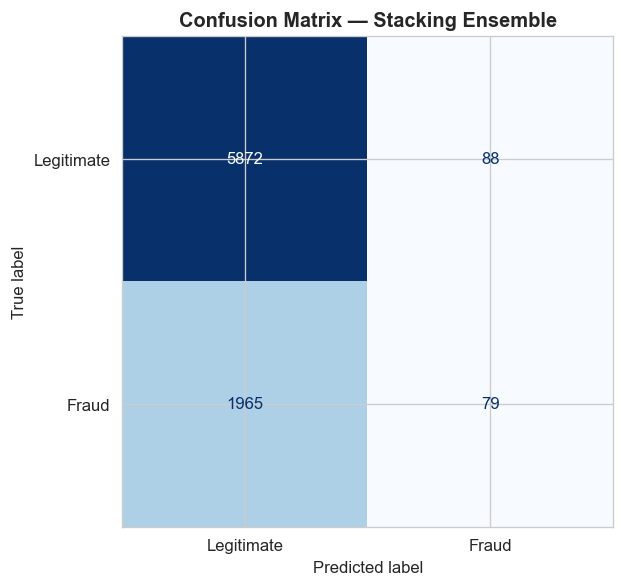

True Positives  (Fraud caught)       : 79
False Negatives (Fraud missed)       : 1,965  ← Financial Risk
False Positives (Legit blocked)      : 88  ← Customer Friction
True Negatives  (Legit approved)     : 5,872


In [46]:
# Confusion Matrix for best model
cm = confusion_matrix(y_test, all_preds[best_model_name])

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Legitimate', 'Fraud'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Confusion Matrix — {best_model_name}', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Positives  (Fraud caught)       : {tp:,}")
print(f"False Negatives (Fraud missed)       : {fn:,}  ← Financial Risk")
print(f"False Positives (Legit blocked)      : {fp:,}  ← Customer Friction")
print(f"True Negatives  (Legit approved)     : {tn:,}")

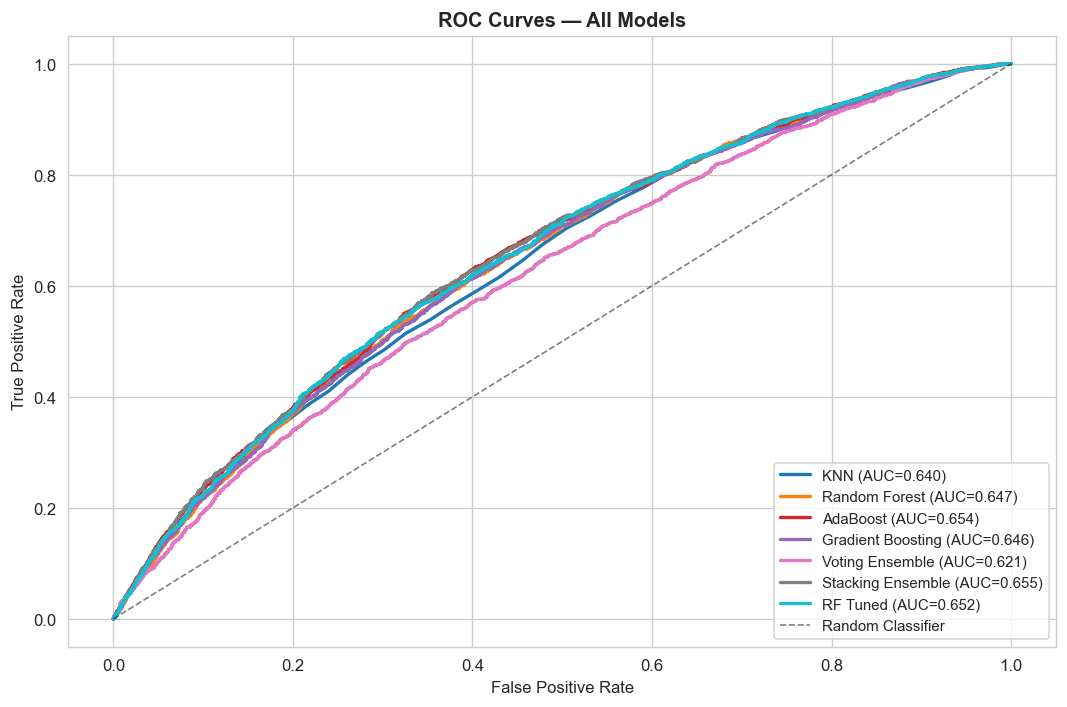

In [47]:
# ROC Curves — all models
fig, ax = plt.subplots(figsize=(9, 6))
colors = plt.cm.tab10(np.linspace(0, 0.9, len(all_probas)))

for (name, proba), color in zip(all_probas.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, lw=2, color=color, label=f"{name} (AUC={auc:.3f})")

ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Random Classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All Models', fontweight='bold', fontsize=12)
ax.legend(fontsize=9, loc='lower right')
plt.tight_layout()
plt.show()

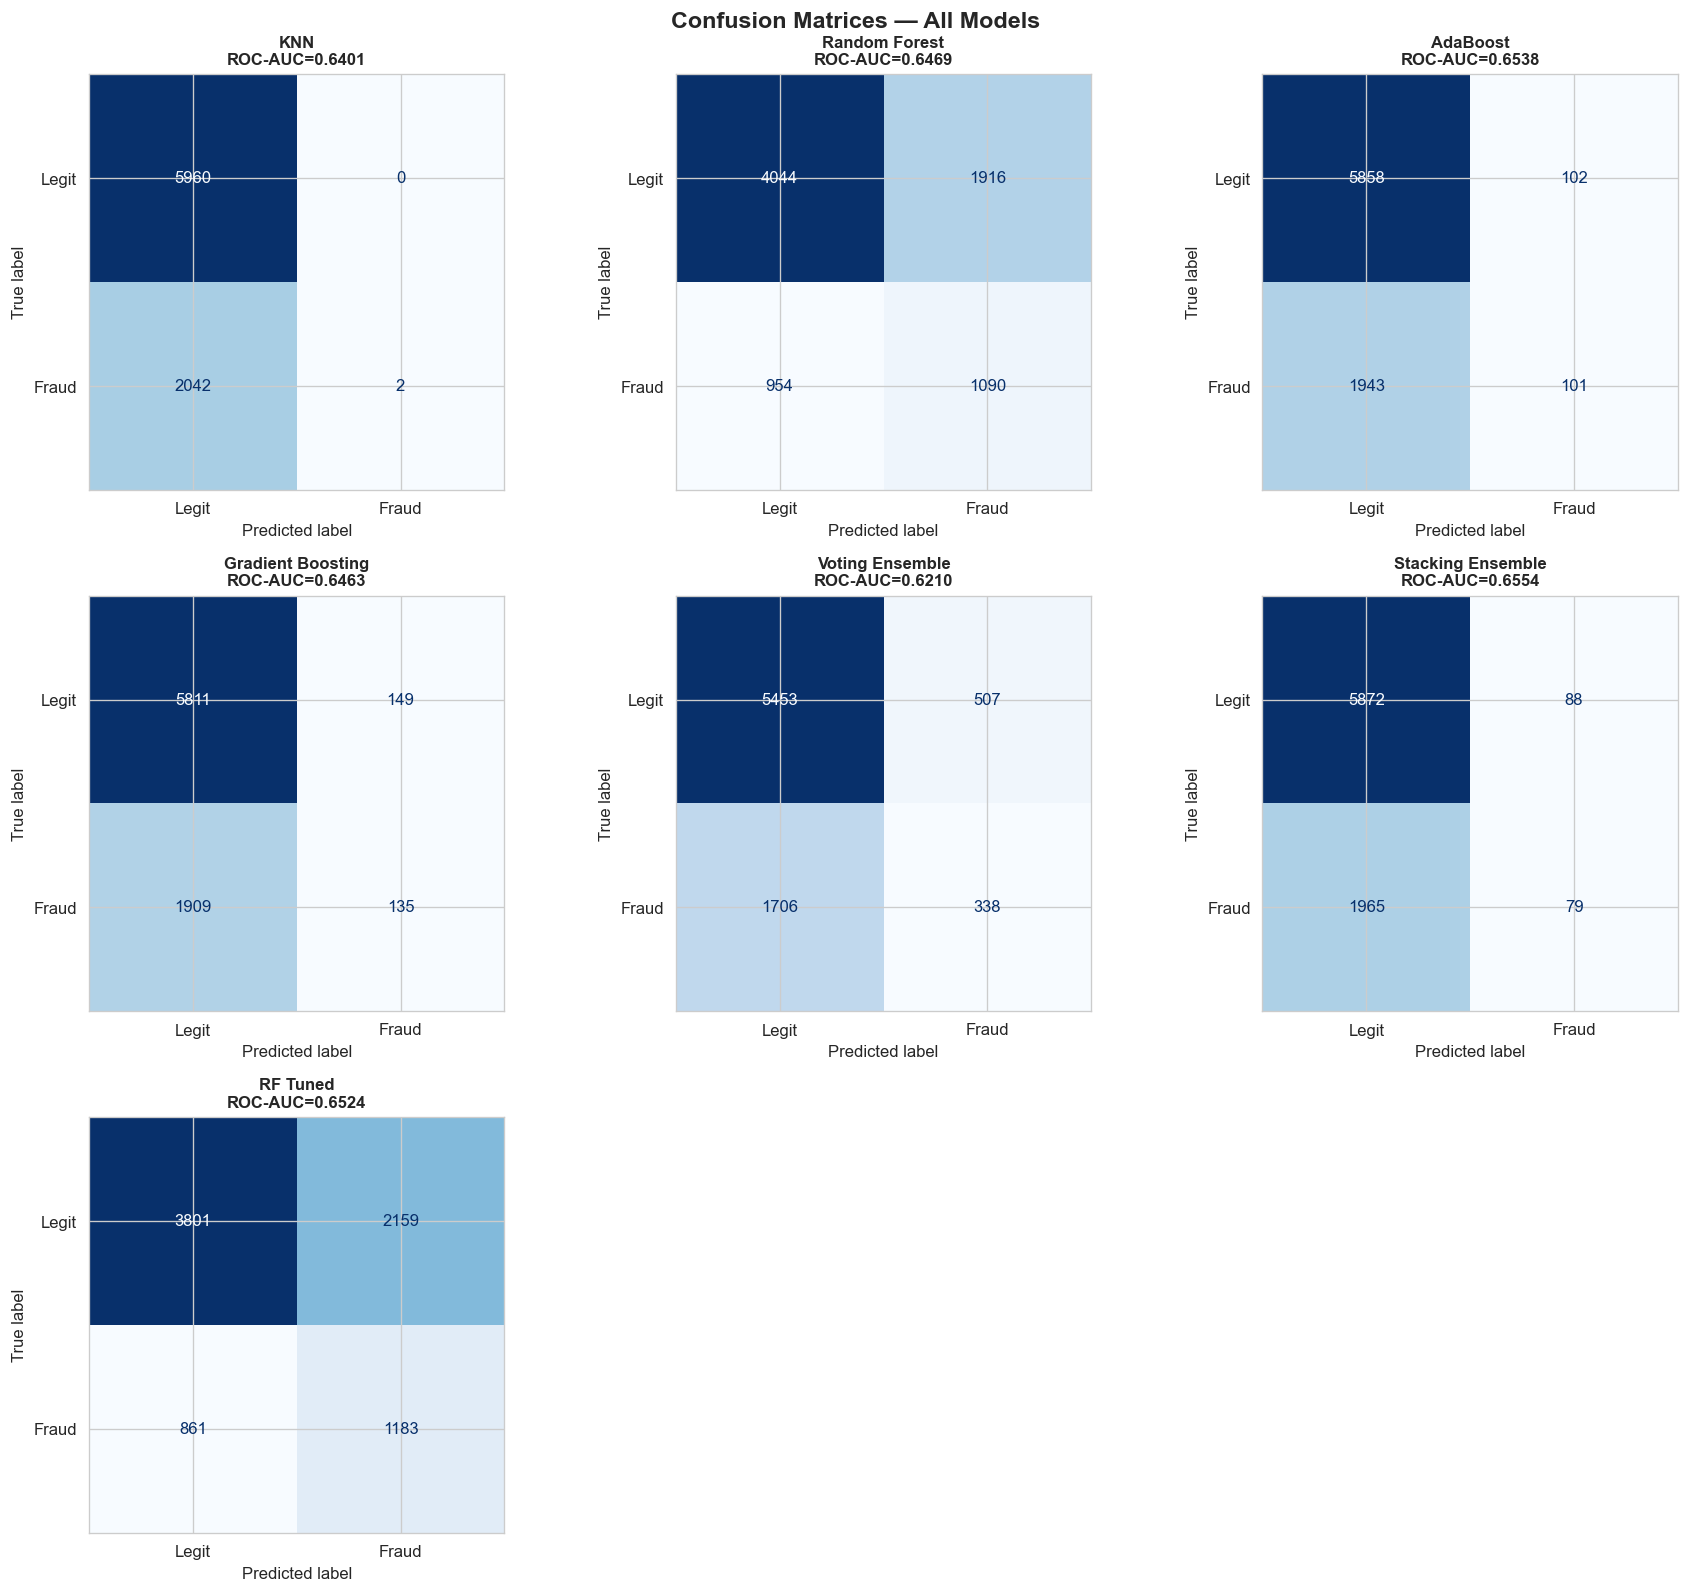

In [48]:
# Confusion Matrices — all models side by side
n_models = len(all_preds)
cols = 3
rows = (n_models + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 4.5))
axes = axes.flatten()

for i, (name, preds) in enumerate(all_preds.items()):
    cm_i = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_i,
                                   display_labels=['Legit', 'Fraud'])
    disp.plot(ax=axes[i], colorbar=False, cmap='Blues')
    auc = roc_auc_score(y_test, all_probas[name])
    axes[i].set_title(f"{name}\nROC-AUC={auc:.4f}", fontweight='bold', fontsize=10)

# Hide unused axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [49]:
# Cross-validation scores for best model
cv_scores = cross_val_score(
    trained_models[best_model_name],
    X_train_sc, y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    scoring='f1',
    n_jobs=-1
)

print(f"Cross-Validation F1 Scores ({best_model_name}):")
for i, s in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {s:.4f}")
print(f"\nMean F1 : {cv_scores.mean():.4f}")
print(f"Std  F1 : {cv_scores.std():.4f}")

Cross-Validation F1 Scores (Stacking Ensemble):
  Fold 1: 0.0638
  Fold 2: 0.0930
  Fold 3: 0.0709
  Fold 4: 0.0949
  Fold 5: 0.0792

Mean F1 : 0.0803
Std  F1 : 0.0121


---
## Step 10 — Compare Model Performance

In [50]:
# Summary table
results_df = pd.DataFrame(all_results).set_index('Model')
results_df.sort_values('ROC-AUC', ascending=False)

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Stacking Ensemble,0.7435,0.4731,0.0386,0.0715,0.6554
AdaBoost,0.7445,0.4975,0.0494,0.0899,0.6538
RF Tuned,0.6227,0.3540,0.5788,0.4393,0.6524
Random Forest,0.6414,0.3626,0.5333,0.4317,0.6469
Gradient Boosting,0.7429,0.4754,0.0660,0.1160,0.6463
KNN,0.7449,1.0000,0.0010,0.0020,0.6401
Voting Ensemble,0.7235,0.4000,0.1654,0.2340,0.6210


In [51]:
# Styled table highlight
results_df.sort_values('ROC-AUC', ascending=False).style \
    .background_gradient(cmap='RdYlGn', subset=['F1-Score', 'ROC-AUC', 'Recall']) \
    .set_caption('Model Performance Comparison — All Metrics')

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Stacking Ensemble,0.743500,0.473100,0.038600,0.071500,0.655400
AdaBoost,0.744500,0.497500,0.049400,0.089900,0.653800
RF Tuned,0.622700,0.354000,0.578800,0.439300,0.652400
Random Forest,0.641400,0.362600,0.533300,0.431700,0.646900
Gradient Boosting,0.742900,0.475400,0.066000,0.116000,0.646300
KNN,0.744900,1.000000,0.001000,0.002000,0.640100
Voting Ensemble,0.723500,0.400000,0.165400,0.234000,0.621000


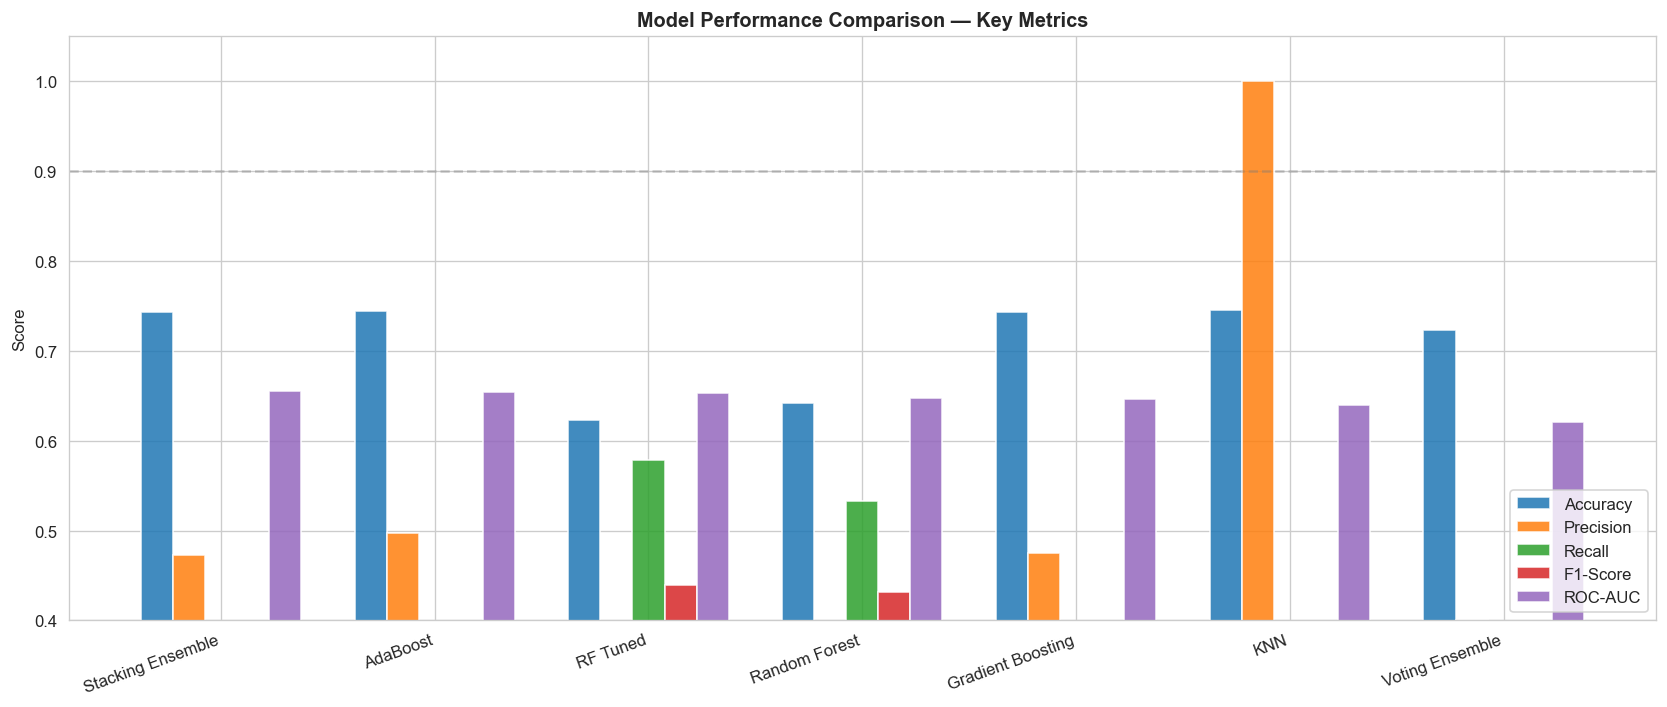

In [52]:
# Bar chart: All models, all key metrics
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
results_sorted  = results_df.sort_values('ROC-AUC', ascending=False)

x     = np.arange(len(results_sorted))
width = 0.15

fig, ax = plt.subplots(figsize=(14, 6))
for i, metric in enumerate(metrics_to_plot):
    ax.bar(x + i * width, results_sorted[metric], width, label=metric, alpha=0.85)

ax.set_xticks(x + width * 2)
ax.set_xticklabels(results_sorted.index, rotation=20, ha='right')
ax.set_ylim(0.4, 1.05)
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison — Key Metrics', fontweight='bold', fontsize=12)
ax.legend(loc='lower right')
ax.axhline(0.9, color='gray', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

### 10.1 — Analyze Feature Importance

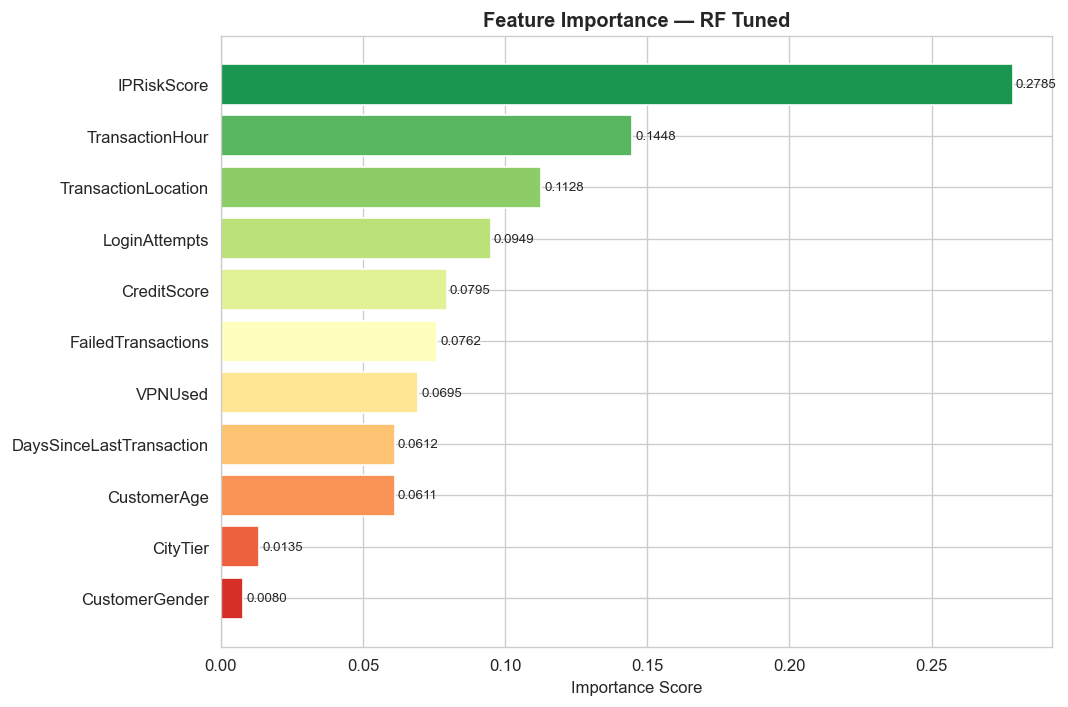


Top 5 most important features:
IPRiskScore            0.278533
TransactionHour        0.144796
TransactionLocation    0.112791
LoginAttempts          0.094908
CreditScore            0.079493
dtype: float64


In [53]:
# Feature importances from the best tree-based model
# Pick RF Tuned or Gradient Boosting — both have feature_importances_
for m_name in [best_model_name, 'RF Tuned', 'Gradient Boosting', 'Random Forest']:
    if m_name in trained_models and hasattr(trained_models[m_name], 'feature_importances_'):
        fi_model_name = m_name
        break

fi_model = trained_models[fi_model_name]
feat_imp = pd.Series(fi_model.feature_importances_, index=SELECTED_FEATURES).sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
colors = plt.cm.RdYlGn(np.linspace(0.1, 0.9, len(feat_imp)))
ax.barh(feat_imp.index, feat_imp.values, color=colors, edgecolor='white')
ax.set_title(f'Feature Importance — {fi_model_name}', fontweight='bold', fontsize=12)
ax.set_xlabel('Importance Score')
for i, v in enumerate(feat_imp.values):
    ax.text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

print("\nTop 5 most important features:")
print(feat_imp.sort_values(ascending=False).head(5))

### 10.2 — Perform Error Analysis

In [54]:
# Error Analysis on the best model's predictions
error_df = X_test.copy()
error_df['Actual']       = y_test.values
error_df['Predicted']    = all_preds[best_model_name]
error_df['FraudProba']   = all_probas[best_model_name]

error_df['ErrorType'] = 'Correct'
error_df.loc[(error_df['Actual'] == 1) & (error_df['Predicted'] == 0), 'ErrorType'] = 'False Negative'
error_df.loc[(error_df['Actual'] == 0) & (error_df['Predicted'] == 1), 'ErrorType'] = 'False Positive'

print("Error Type Counts:")
print(error_df['ErrorType'].value_counts())
print()
print(f"False Negative Rate (Missed Fraud): {(error_df['ErrorType']=='False Negative').sum() / (error_df['Actual']==1).sum() * 100:.2f}%")
print(f"False Positive Rate (Wrong Blocks): {(error_df['ErrorType']=='False Positive').sum() / (error_df['Actual']==0).sum() * 100:.2f}%")

Error Type Counts:
ErrorType
Correct           5951
False Negative    1965
False Positive      88
Name: count, dtype: int64

False Negative Rate (Missed Fraud): 96.14%
False Positive Rate (Wrong Blocks): 1.48%


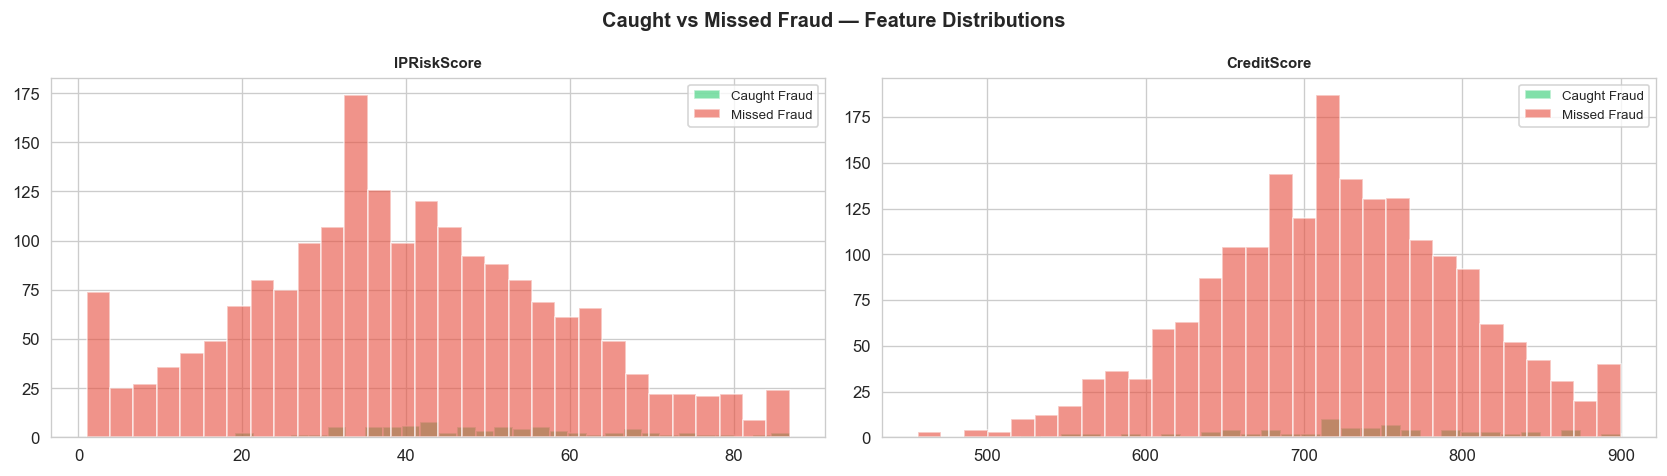

In [56]:
# Profile of False Negatives (Missed Frauds)
fn_df = error_df[error_df['ErrorType'] == 'False Negative']
tp_df = error_df[(error_df['Actual'] == 1) & (error_df['Predicted'] == 1)]

# Before (hardcoded — breaks if column was dropped)
compare_num = ['TransactionAmount', 'IPRiskScore', 'AccountBalance', 'CreditScore']

# After (safe — checks what actually exists in error_df)
preferred = ['TransactionAmount', 'IPRiskScore', 'AccountBalance', 'CreditScore']
compare_num = [c for c in preferred if c in error_df.columns]
if not compare_num:   # fallback if none of the preferred survived selection
    compare_num = error_df.select_dtypes(include='number').columns.tolist()
    compare_num = [c for c in compare_num if c not in ('Actual','Predicted','FraudProba')][:4]

fig, axes = plt.subplots(1, len(compare_num), figsize=(14, 4))
for ax, col in zip(axes, compare_num):
    ax.hist(tp_df[col], bins=30, alpha=0.6, color='#2ecc71', label='Caught Fraud')
    ax.hist(fn_df[col], bins=30, alpha=0.6, color='#e74c3c', label='Missed Fraud')
    ax.set_title(col, fontsize=9, fontweight='bold')
    ax.legend(fontsize=8)

plt.suptitle('Caught vs Missed Fraud — Feature Distributions', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()



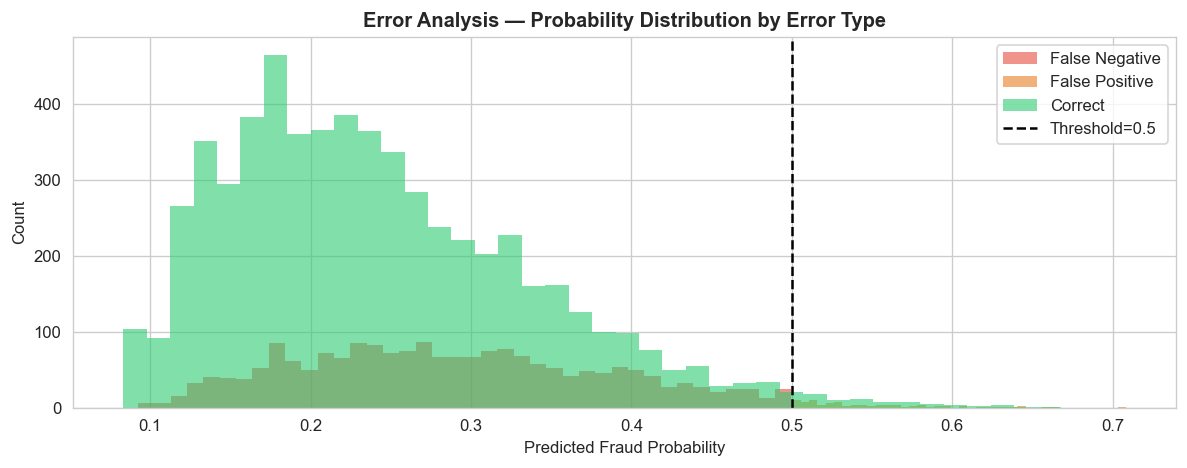

In [57]:
# Probability distribution of errors
fig, ax = plt.subplots(figsize=(10, 4))
for etype, color in [('False Negative', '#e74c3c'), ('False Positive', '#e67e22'), ('Correct', '#2ecc71')]:
    subset = error_df[error_df['ErrorType'] == etype]['FraudProba']
    ax.hist(subset, bins=40, alpha=0.6, color=color, label=etype, edgecolor='none')

ax.axvline(0.5, color='black', linestyle='--', lw=1.5, label='Threshold=0.5')
ax.set_xlabel('Predicted Fraud Probability')
ax.set_ylabel('Count')
ax.set_title('Error Analysis — Probability Distribution by Error Type', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

---
## Step 11 — Generate Business Insights

In [58]:
# Risk Score Assignment using best model probabilities
def assign_risk_tier(prob):
    if   prob >= 0.80: return 'CRITICAL'
    elif prob >= 0.60: return 'HIGH'
    elif prob >= 0.40: return 'MEDIUM'
    elif prob >= 0.20: return 'LOW'
    else:              return 'MINIMAL'

error_df['RiskTier'] = error_df['FraudProba'].apply(assign_risk_tier)

RISK_ORDER  = ['CRITICAL', 'HIGH', 'MEDIUM', 'LOW', 'MINIMAL']
RISK_COLORS = ['#c0392b', '#e67e22', '#f1c40f', '#27ae60', '#2980b9']

risk_summary = error_df.groupby('RiskTier').agg(
    Total=('Actual', 'count'),
    FraudCount=('Actual', 'sum'),
).reindex(RISK_ORDER)
risk_summary['FraudRate %'] = (risk_summary['FraudCount'] / risk_summary['Total'] * 100).round(1)

print("Risk Tier Summary:")
print(risk_summary)

Risk Tier Summary:
           Total  FraudCount  FraudRate %
RiskTier                                 
CRITICAL     NaN         NaN          NaN
HIGH        22.0        10.0         45.5
MEDIUM     733.0       339.0         46.2
LOW       4534.0      1293.0         28.5
MINIMAL   2715.0       402.0         14.8


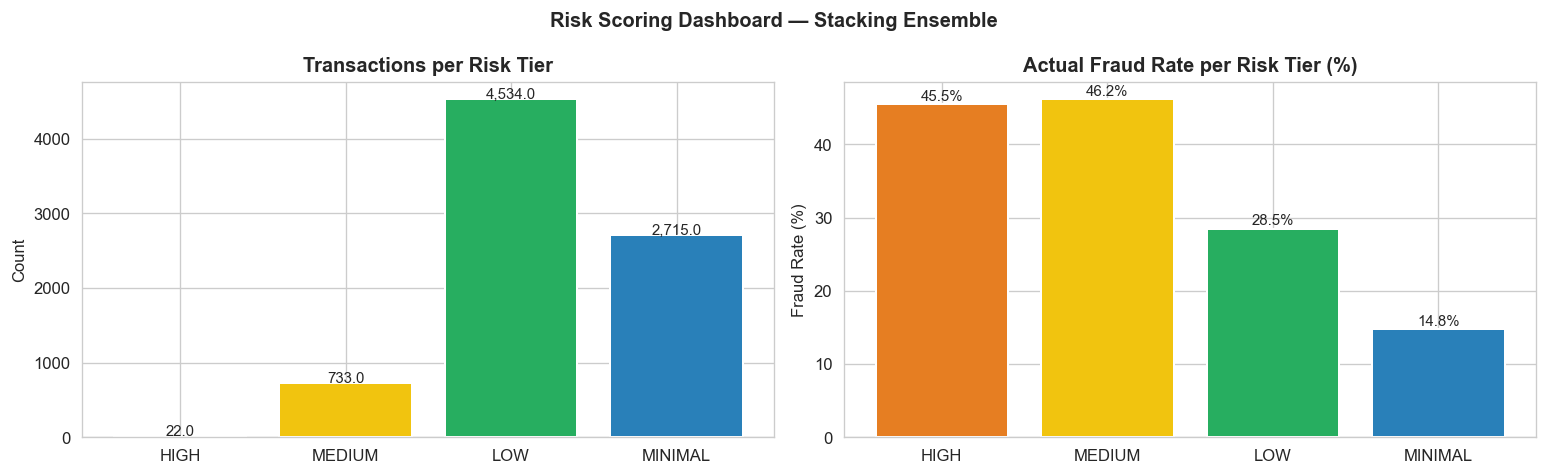

In [59]:
# Risk Tier Visualisation
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(risk_summary.index, risk_summary['Total'], color=RISK_COLORS, edgecolor='white', linewidth=1.2)
axes[0].set_title('Transactions per Risk Tier', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(risk_summary['Total']):
    axes[0].text(i, v + 5, f'{v:,}', ha='center', fontsize=9)

axes[1].bar(risk_summary.index, risk_summary['FraudRate %'], color=RISK_COLORS, edgecolor='white', linewidth=1.2)
axes[1].set_title('Actual Fraud Rate per Risk Tier (%)', fontweight='bold')
axes[1].set_ylabel('Fraud Rate (%)')
for i, v in enumerate(risk_summary['FraudRate %']):
    axes[1].text(i, v + 0.5, f'{v}%', ha='center', fontsize=9)

plt.suptitle(f'Risk Scoring Dashboard — {best_model_name}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [60]:
# Business Impact Quantification
avg_fraud_amount = df.loc[df['IsFraud'] == 1, 'TransactionAmount'].median()
residual_loss    = fn * avg_fraud_amount
fraud_saved      = tp * avg_fraud_amount

print("=" * 58)
print("  BUSINESS IMPACT SUMMARY")
print("=" * 58)
print(f"  Fraud transactions in test set  : {(y_test==1).sum():>6,}")
print(f"  Correctly Flagged (True Pos)    : {tp:>6,}")
print(f"  Missed Frauds     (False Neg)   : {fn:>6,}  ← Exposure")
print(f"  False Alarms      (False Pos)   : {fp:>6,}  ← Friction")
print(f"  Avg Fraud Amount  (median)      : ₹{avg_fraud_amount:>10,.2f}")
print(f"  Estimated Savings               : ₹{fraud_saved:>10,.2f}")
print(f"  Residual Risk Exposure          : ₹{residual_loss:>10,.2f}")
print("=" * 58)

  BUSINESS IMPACT SUMMARY
  Fraud transactions in test set  :  2,044
  Correctly Flagged (True Pos)    :     79
  Missed Frauds     (False Neg)   :  1,965  ← Exposure
  False Alarms      (False Pos)   :     88  ← Friction
  Avg Fraud Amount  (median)      : ₹  8,459.10
  Estimated Savings               : ₹668,268.90
  Residual Risk Exposure          : ₹16,622,131.50


In [61]:
# Final Business Insights Summary
insights = """
╔══════════════════════════════════════════════════════════════════════╗
║              KEY BUSINESS INSIGHTS & RECOMMENDATIONS                ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  FRAUD PATTERNS OBSERVED                                             ║
║  ─────────────────────────                                           ║
║  • International transactions carry the highest fraud risk.          ║
║  • Luxury & Gaming merchant categories show elevated fraud rates.    ║
║  • VPN usage and multiple device switching are strong fraud signals. ║
║  • High IP Risk Score (>70) strongly correlates with fraud.          ║
║  • Late-night transactions (12am–5am) have disproportionate risk.   ║
║  • Customers with Poor credit scores submitting high-value txns      ║
║    should trigger enhanced verification.                             ║
║                                                                      ║
║  RECOMMENDED ACTIONS BY RISK TIER                                    ║
║  ──────────────────────────────────                                  ║
║  CRITICAL (≥80% probability) → Block + Analyst review immediately   ║
║  HIGH     (60–80%)           → Soft block + Step-up authentication  ║
║  MEDIUM   (40–60%)           → Flag for async review queue           ║
║  LOW      (20–40%)           → Allow + passive monitoring            ║
║  MINIMAL  (<20%)             → Allow with standard logging           ║
║                                                                      ║
║  MODEL DEPLOYMENT NOTES                                              ║
║  ───────────────────────                                             ║
║  • Deploy best model as a real-time REST API scoring service.        ║
║  • Retrain monthly or when fraud drift exceeds 2%.                  ║
║  • Build analyst feedback loop to improve labels over time.          ║
║  • Add velocity features (txns per hour/day) for next model version.║
║                                                                      ║
╚══════════════════════════════════════════════════════════════════════╝
"""
print(insights)


╔══════════════════════════════════════════════════════════════════════╗
║              KEY BUSINESS INSIGHTS & RECOMMENDATIONS                ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  FRAUD PATTERNS OBSERVED                                             ║
║  ─────────────────────────                                           ║
║  • International transactions carry the highest fraud risk.          ║
║  • Luxury & Gaming merchant categories show elevated fraud rates.    ║
║  • VPN usage and multiple device switching are strong fraud signals. ║
║  • High IP Risk Score (>70) strongly correlates with fraud.          ║
║  • Late-night transactions (12am–5am) have disproportionate risk.   ║
║  • Customers with Poor credit scores submitting high-value txns      ║
║    should trigger enhanced verification.                             ║
║                                                   